In [150]:
# Core analysis libraries:
# - pandas for tabular data manipulation
# - matplotlib/seaborn for visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Reusable formatter for large business numbers.
# Example: 12,500 -> 12.5K, 2,300,000 -> 2.3M
# This keeps axis labels readable for non-technical viewers.
def human_readable_number(value, _):
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f'{value/1_000_000_000:.1f}B'
    if abs_value >= 1_000_000:
        return f'{value/1_000_000:.1f}M'
    if abs_value >= 1_000:
        return f'{value/1_000:.1f}K'
    return f'{value:,.0f}'

# Simple integer formatter (used for day-based charts).
def integer_with_commas(value, _):
    return f'{value:,.0f}'


In [151]:
# Load the source dataset containing invoice, product, market, and geography fields.
# Keep the CSV in the notebook directory, or replace with an absolute path.
df = pd.read_csv('Meropenem_FY22_to_FY25_with_MarketCategory.csv')


In [152]:
# Convert 'Invoice Date' from text to pandas datetime objects.
# dayfirst=True is intended for dates like DD/MM/YYYY or DD-Mon-YYYY.
# If raw formats are mixed, pandas may warn and parse row-by-row.
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], dayfirst=True)


/var/folders/2h/9t6yflpn4970wwb1dkydnfp80000gn/T/ipykernel_1980/3649950825.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], dayfirst=True)


/var/folders/2h/9t6yflpn4970wwb1dkydnfp80000gn/T/ipykernel_1980/3121454820.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yoy_growth.index, y=yoy_growth.values, palette='Blues_d')


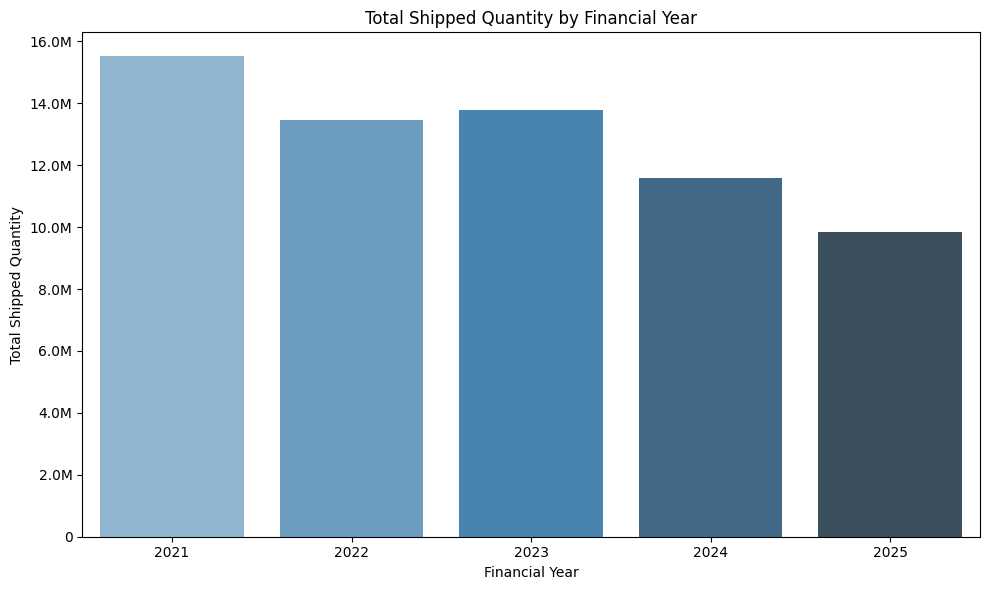

In [153]:
# 1) Year-over-Year (YoY) Growth Analysis
# Aggregate total shipped quantity at financial-year level.
yoy_growth = df.groupby('Financial Year')['Total Qty'].sum()

# Visualize YoY growth with a bar chart.
plt.figure(figsize=(10, 6))
sns.barplot(x=yoy_growth.index, y=yoy_growth.values, palette='Blues_d')
plt.title('Total Shipped Quantity by Financial Year')
plt.xlabel('Financial Year')
plt.ylabel('Total Shipped Quantity')
plt.gca().yaxis.set_major_formatter(FuncFormatter(human_readable_number))
plt.tight_layout()
plt.show()

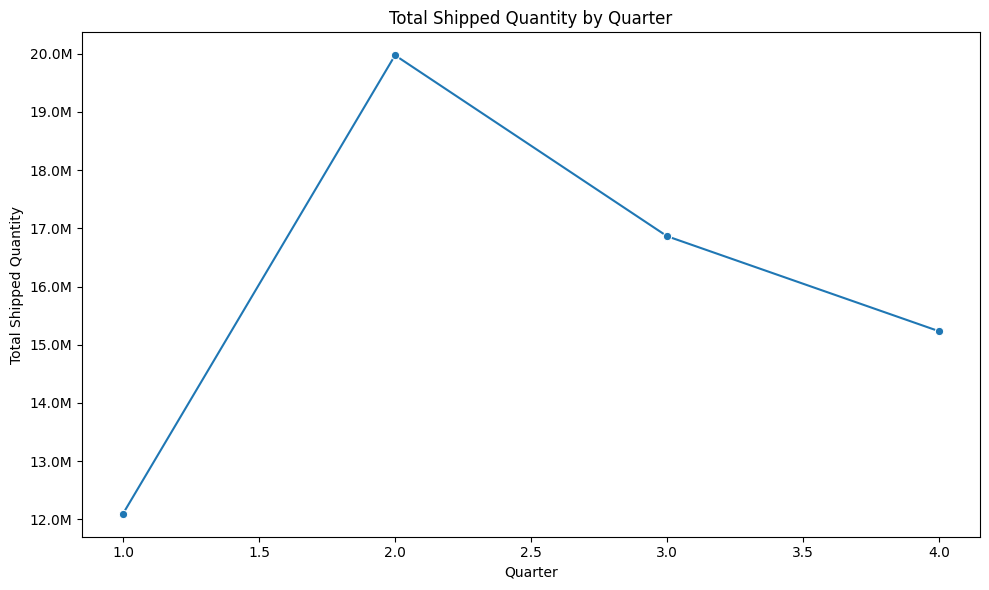

In [154]:
# 2) Quarterly Seasonality Pattern
# Aggregate total quantity by quarter (useful to spot recurring demand peaks).
quarterly_demand = df.groupby('Quarter')['Total Qty'].sum()
# Visualize quarterly demand with a line plot.
plt.figure(figsize=(10, 6))
sns.lineplot(x=quarterly_demand.index, y=quarterly_demand.values, marker='o')
plt.title('Total Shipped Quantity by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Total Shipped Quantity')
plt.gca().yaxis.set_major_formatter(FuncFormatter(human_readable_number))
plt.tight_layout()
plt.show()


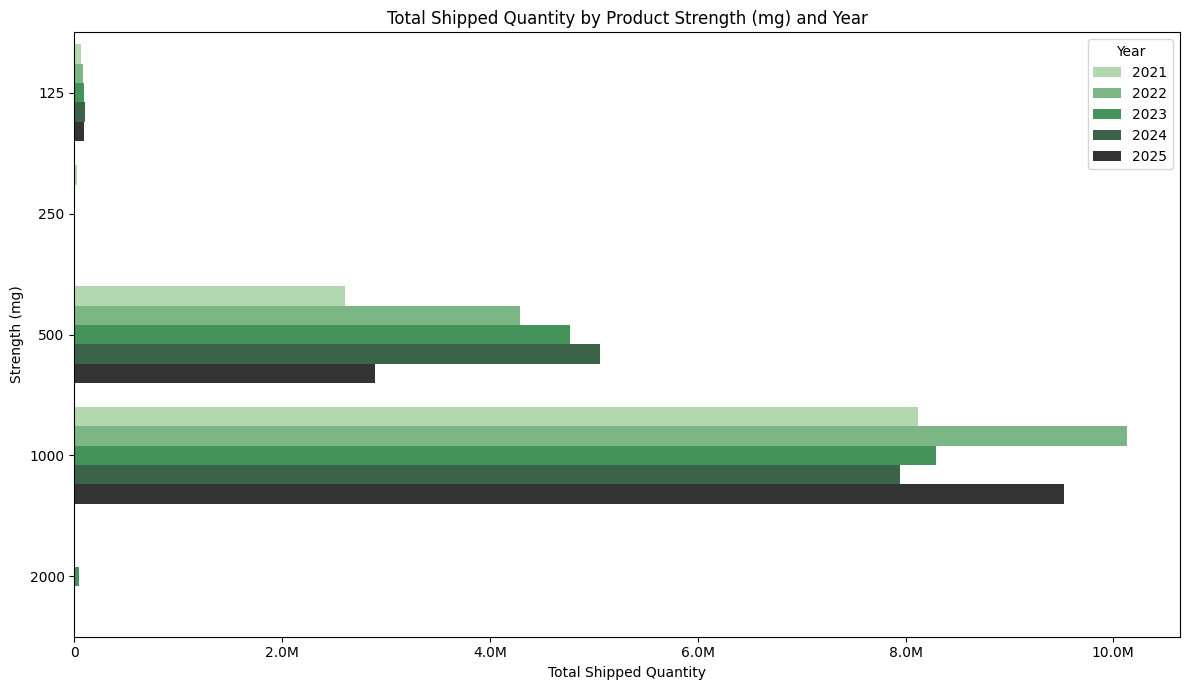

In [155]:
# 3) Strength Distribution Mix
# Make sure you have a Year column (replace 'Shipment Date' with your actual date column)
df['Year'] = pd.to_datetime(df['Invoice Date']).dt.year

# Strength distribution split by year
strength_mix = (
    df.groupby(['Strength In MG', 'Year'], as_index=False)['Total Qty']
      .sum()
)

strength_mix['Strength In MG'] = strength_mix['Strength In MG'].astype(str)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=strength_mix,
    x='Total Qty',
    y='Strength In MG',
    hue='Year',
    palette='Greens_d'
)
plt.title('Total Shipped Quantity by Product Strength (mg) and Year')
plt.xlabel('Total Shipped Quantity')
plt.ylabel('Strength (mg)')
plt.gca().xaxis.set_major_formatter(FuncFormatter(human_readable_number))
plt.tight_layout()
plt.show()


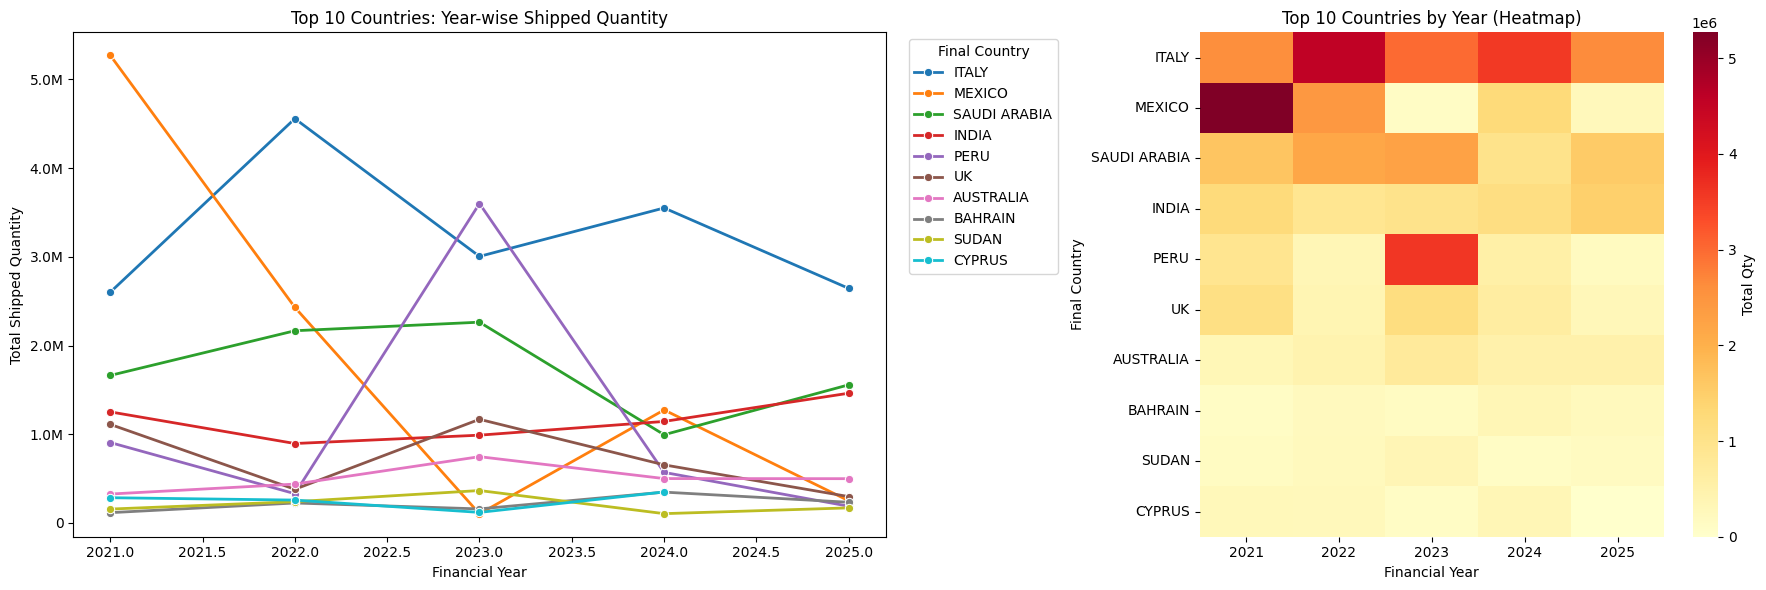

In [156]:
# 4) Geographic Concentration Risk
# Top 10 countries overall
top10_countries = (
    df.groupby('Final Country', as_index=False)['Total Qty']
      .sum()
      .nlargest(10, 'Total Qty')['Final Country']
)

# Year-wise qty for those countries
plot_df = (
    df[df['Final Country'].isin(top10_countries)]
      .groupby(['Financial Year', 'Final Country'], as_index=False)['Total Qty']
      .sum()
)

country_order = (
    df[df['Final Country'].isin(top10_countries)]
      .groupby('Final Country')['Total Qty']
      .sum()
      .sort_values(ascending=False)
      .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1.4, 1]})

# 1) Line plot: year-wise trend
sns.lineplot(
    data=plot_df,
    x='Financial Year',
    y='Total Qty',
    hue='Final Country',
    marker='o',
    linewidth=2,
    hue_order=country_order,
    ax=axes[0]
)
axes[0].set_title('Top 10 Countries: Year-wise Shipped Quantity')
axes[0].set_xlabel('Financial Year')
axes[0].set_ylabel('Total Shipped Quantity')
axes[0].yaxis.set_major_formatter(FuncFormatter(human_readable_number))
axes[0].legend(title='Final Country', bbox_to_anchor=(1.02, 1), loc='upper left')

# 2) Heatmap: easy year-country comparison
heat_df = (
    plot_df.pivot(index='Final Country', columns='Financial Year', values='Total Qty')
           .fillna(0)
           .loc[country_order]
)
sns.heatmap(heat_df, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Total Qty'})
axes[1].set_title('Top 10 Countries by Year (Heatmap)')
axes[1].set_xlabel('Financial Year')
axes[1].set_ylabel('Final Country')

plt.tight_layout()
plt.show()



/var/folders/2h/9t6yflpn4970wwb1dkydnfp80000gn/T/ipykernel_1980/1437999522.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_performance.values, y=dept_performance.index, palette='Purples_d')


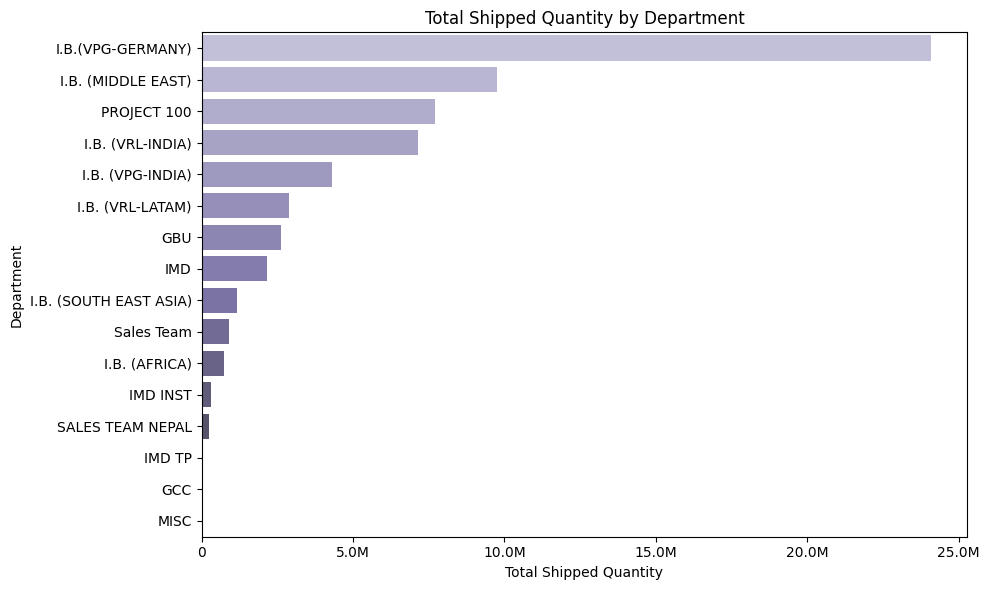

In [157]:
# 5) Departmental Volume Leaderboard
# Rank departments by total shipped quantity (highest first).
dept_performance = (
    df.groupby('Department')['Total Qty']
      .sum()
      .sort_values(ascending=False)
)
# Visualize with a horizontal bar chart.
plt.figure(figsize=(10, 6))
sns.barplot(x=dept_performance.values, y=dept_performance.index, palette='Purples_d')
plt.title('Total Shipped Quantity by Department')
plt.xlabel('Total Shipped Quantity')
plt.ylabel('Department')
plt.gca().xaxis.set_major_formatter(FuncFormatter(human_readable_number))
plt.tight_layout()
plt.show()

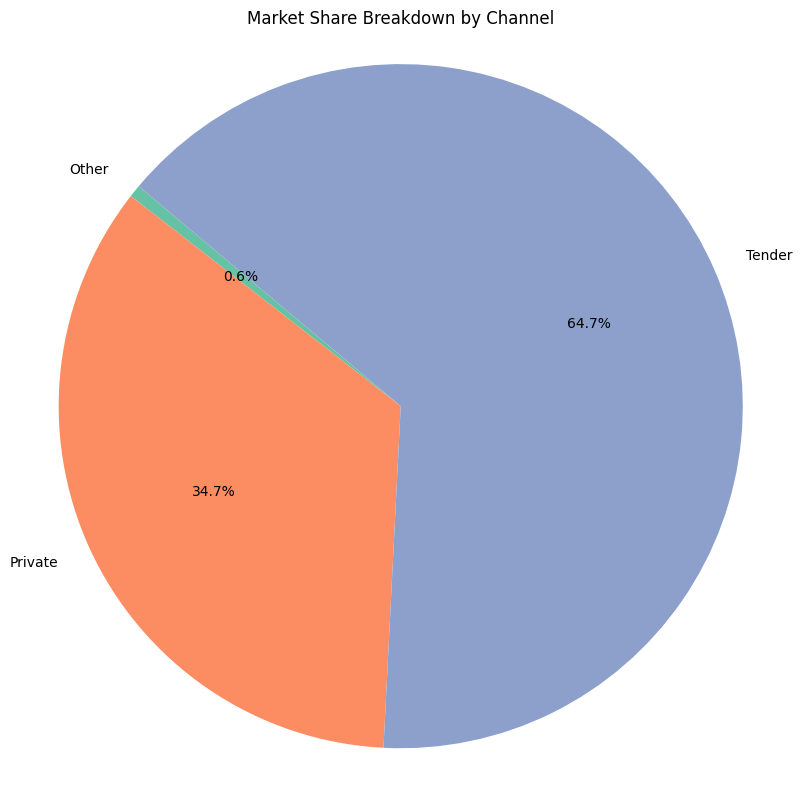

In [158]:
# 6) Market Share Breakdown (Tender vs Private vs Other)
# Channel-wise volume split.
market_share = df.groupby('Market')['Total Qty'].sum()
# Visualize market share with a pie chart.
plt.figure(figsize=(8, 8))
colors = sns.color_palette('Set2', len(market_share))
plt.pie(market_share.values, labels=market_share.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Market Share Breakdown by Channel')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.tight_layout()
plt.show()


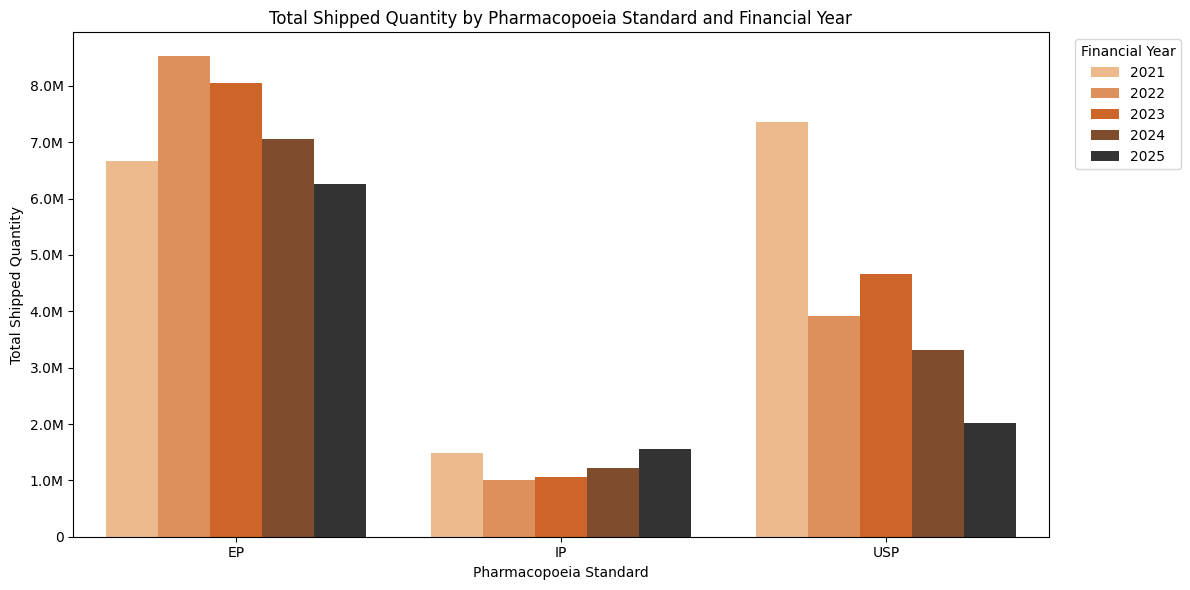

In [159]:
# 7) Pharmacopoeia Compliance Overview
# Volume distribution by regulatory standard and year.
pharmacopoeia_mix = (
    df.groupby(['Pharmacopoeia', 'Financial Year'], as_index=False)['Total Qty']
      .sum()
)

# Visualize with a grouped bar chart.
plt.figure(figsize=(12, 6))
sns.barplot(
    data=pharmacopoeia_mix,
    x='Pharmacopoeia',
    y='Total Qty',
    hue='Financial Year',
    palette='Oranges_d'
)

plt.title('Total Shipped Quantity by Pharmacopoeia Standard and Financial Year')
plt.xlabel('Pharmacopoeia Standard')
plt.ylabel('Total Shipped Quantity')
plt.gca().yaxis.set_major_formatter(FuncFormatter(human_readable_number))
plt.legend(title='Financial Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [160]:
# NumPy import (handy for numeric helpers in advanced analysis).
import numpy as np


In [161]:
# Build df2 for the exploratory block.
# Reuse in-memory df when available; fallback to CSV if starting from this section.
if 'df' in globals():
    df2 = df.copy()
else:
    df2 = pd.read_csv('Meropenem_FY22_to_FY25_with_MarketCategory.csv')


In [162]:
# Build date-derived helper fields used in downstream analysis.
df2['Invoice Date'] = pd.to_datetime(df2['Invoice Date'], dayfirst=True, errors='coerce')
df2 = df2.dropna(subset=['Invoice Date']).copy()
df2['Month'] = df2['Invoice Date'].dt.month
df2['Day_Month'] = df2['Invoice Date'].dt.strftime('%d-%b')


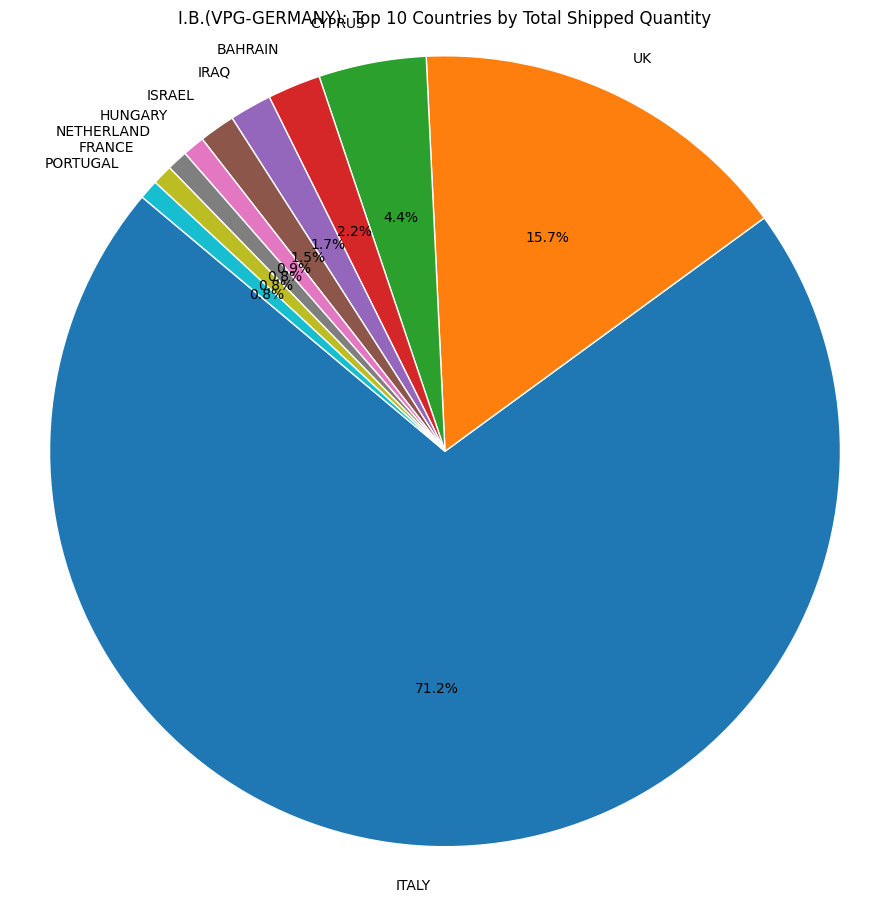

In [217]:
# 8) Strategic Project Lifecycle Analysis (PROJECT 100)
# Filter PROJECT 100 records, then aggregate units and API requirement by country.
# Filter
dept_data = df2[df2['Department'] == 'I.B.(VPG-GERMANY)'].copy()

# Aggregate by country
p100_stats = (
    dept_data
    .groupby('Final Country', as_index=True)[['Total Qty', 'API Requirement in KG']]
    .sum()
)



# Pie chart: Top 10 countries by Total Qty
top10 = p100_stats.sort_values('Total Qty', ascending=False).head(10)

plt.figure(figsize=(9, 9))
plt.pie(
    top10['Total Qty'],
    labels=top10.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('I.B.(VPG-GERMANY): Top 10 Countries by Total Shipped Quantity')
plt.axis('equal')  # keeps pie circular
plt.tight_layout()
plt.show()



In [164]:
# 9) Strength-to-Department Niche Specialization
# Create Department x Strength matrix (missing combinations set to 0).
niche_analysis = df2.groupby(['Department', 'Strength In MG'])['Total Qty'].sum().unstack().fillna(0)
# Show GCC row to verify whether demand is concentrated at specific strength(s).
print('Department Strength Niche (Focus on GCC 2000mg):')
print(niche_analysis.loc[['GCC']])


Department Strength Niche (Focus on GCC 2000mg):
Strength In MG  125   250   500   1000    2000
Department                                    
GCC              0.0   0.0   0.0   0.0  9804.0


In [ ]:
# 10) Regulatory Standards Mapping (Pharmacopoeia vs Country)
# Build country-standard matrix, then rank countries by overall total volume.
reg_map = df2.groupby(['Final Country', 'Pharmacopoeia'])['Total Qty'].sum().unstack().fillna(0)
print('Top 10 Countries by Total Volume in Regulatory Mapping:')
print(reg_map.sum(axis=1).nlargest(10))



Top 10 Countries by Total Volume in Regulatory Mapping:
Final Country
ITALY           16354216.0
MEXICO           9328330.0
SAUDI ARABIA     8643023.0
INDIA            5743418.0
PERU             5595290.0
UK               3611096.0
AUSTRALIA        2510430.0
BAHRAIN          1080280.0
SUDAN            1036787.0
CYPRUS           1010940.0
dtype: float64


In [166]:
# 11) Fiscal Year-End Target Pushes (March 31 Analysis)
# Isolate rows invoiced on 31-Mar and sum quantity by financial year.
march_31_push = df2[df2['Day_Month'] == '31-Mar'].groupby('Financial Year')['Total Qty'].sum()
print('March 31st Volume Push by Financial Year:')
print(march_31_push)


March 31st Volume Push by Financial Year:
Financial Year
2021     267078
2022     833583
2023    1130901
2024     312458
Name: Total Qty, dtype: int64


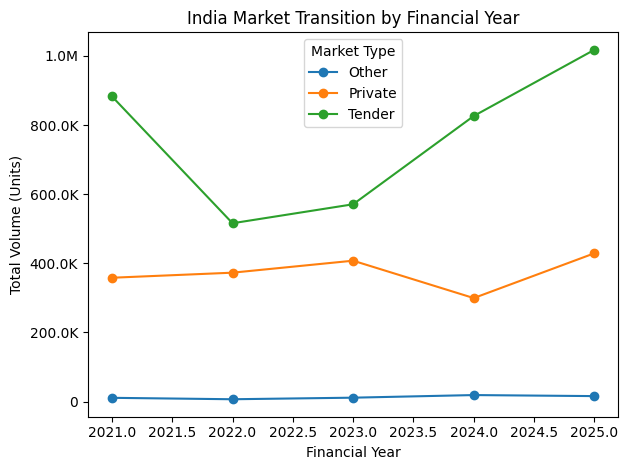

In [167]:
# 12) Market Transition Trends for India
# Compare yearly channel movement (Tender/Private/Other) in India.
india_market = (
    df2[df2['Final Country'] == 'INDIA']
    .groupby(['Financial Year', 'Market'])['Total Qty']
    .sum()
    .unstack(fill_value=0)
)
ax = india_market.plot(kind='line', marker='o', title='India Market Transition by Financial Year')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Total Volume (Units)')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
ax.legend(title='Market Type')
plt.tight_layout()
plt.show()


In [168]:
# 13) API Utilization and Wastage Proportionality
# API_Per_Unit_MG = actual API used (mg) / theoretical API required (Qty * strength mg).
# Mean near ~1.41 suggests stable conversion+wastage behavior.
df2['API_Per_Unit_MG'] = (df2['API Requirement in KG'] * 1000000) / (df2['Total Qty'] * df2['Strength In MG'])
print('Average API Utilization Ratio (Expected near wastage factor):')
print(df2['API_Per_Unit_MG'].mean())


Average API Utilization Ratio (Expected near wastage factor):
1.410009283118403


Departmental Efficiency (Units per KG of API):
                        Total Qty  API Requirement in KG  API_Efficiency
Department                                                              
IMD INST                   320210              265.90485     1204.227753
I.B. (MIDDLE EAST)        9763616            10181.87720      958.921013
GBU                       2636356             3006.00894      877.028662
I.B. (VRL-INDIA)          7149598             8226.24104      869.120898
IMD                       2152015             2484.74149      866.092110
I.B. (VRL-LATAM)          2885310             3403.54965      847.735540
Sales Team                 910289             1074.58323      847.108883
I.B.(VPG-GERMANY)        24079595            29636.24715      812.504865
I.B. (VPG-INDIA)          4317895             5315.05635      812.389317
PROJECT 100               7704330             9511.15149      810.031257
IMD TP                      64300               79.60860      807.701680
MISC

/var/folders/2h/9t6yflpn4970wwb1dkydnfp80000gn/T/ipykernel_1980/2263778585.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_comp['API_Efficiency'], y=dept_comp.index, palette='coolwarm')


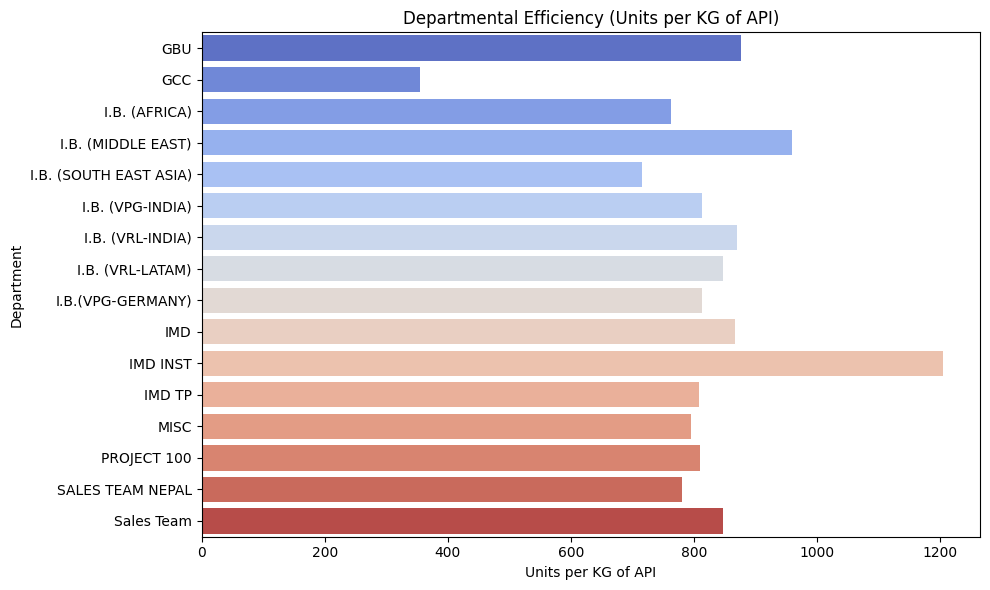

In [218]:
# 14) Departmental Market Share Internal Competition (Year-wise)
# Compute each department's total units and total API usage by financial year.
# API_Efficiency expresses output per KG of API consumed.
dept_comp = (
    df2.groupby(['Financial Year', 'Department'], as_index=False)
    .agg({'Total Qty': 'sum', 'API Requirement in KG': 'sum'})
)
dept_comp['API_Efficiency'] = dept_comp['Total Qty'] / dept_comp['API Requirement in KG']

print('Departmental Efficiency by Financial Year (Units per KG of API):')
print(dept_comp.sort_values(by=['Financial Year', 'API_Efficiency'], ascending=[True, False]))

# Visualize departmental efficiency with a horizontal bar chart split by year.
plt.figure(figsize=(12, 7))
sns.barplot(
    data=dept_comp,
    x='API_Efficiency',
    y='Department',
    hue='Financial Year',
    palette='coolwarm'
)
plt.title('Departmental Efficiency by Financial Year (Units per KG of API)')
plt.xlabel('Units per KG of API')
plt.ylabel('Department')
plt.legend(title='Financial Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [170]:
# 15) High-Frequency Cluster Analysis (GBU wave identification)
# Count number of GBU transactions per invoice date and show top spikes.
gbu_clusters = df2[df2['Department'] == 'GBU'].groupby('Invoice Date').size().nlargest(5)
print('Top 5 High-Frequency Logistical Clusters (GBU):')
print(gbu_clusters)


Top 5 High-Frequency Logistical Clusters (GBU):
Invoice Date
2023-08-16    247
2024-09-20    171
2024-03-27    149
2024-08-20    137
2023-12-19    133
dtype: int64


In [171]:
# 16) Territorial Strength Preferences
# Country x Strength matrix to compare dosage preference by geography.
territory_pref = df2.groupby(['Final Country', 'Strength In MG'])['Total Qty'].sum().unstack()
print('Strength Preference for Key Markets (Vietnam, Mexico, South Africa):')
print(territory_pref.loc[['VIETNAM', 'MEXICO', 'SOUTH AFRICA']])


Strength Preference for Key Markets (Vietnam, Mexico, South Africa):
Strength In MG  125   250        500        1000  2000
Final Country                                         
VIETNAM          NaN   NaN    27000.0   226020.0   NaN
MEXICO           NaN   NaN  2346665.0  6981665.0   NaN
SOUTH AFRICA     NaN   NaN    38450.0   167357.0   NaN


In [172]:
# 17) Emerging vs Legacy Market Velocity
# Early markets: present on/before FY22.
# Late markets: present in FY24 and beyond.
# Emerging markets are those appearing only in late period.
early_markets = set(df2[df2['Financial Year'] <= 2022]['Final Country'].unique())
late_markets = set(df2[df2['Financial Year'] >= 2024]['Final Country'].unique())
emerging = late_markets - early_markets
print('Emerging Markets (New in FY24/25):')
print(emerging)


Emerging Markets (New in FY24/25):
{'LITHUANIA', 'ESWATINI', 'MALTA', 'CAMBODIA', 'LESOTHO', 'LIBYA', 'GERMANY', 'FRANCE', 'MOLDOVA', 'SERBIA', 'PALESTINE', 'EI SALVADOR', 'THAILAND', 'HUNGARY', 'BULGARIA'}


In [173]:
# 18) Transaction Size Outlier Analysis
# Quantile bounds help flag unusually large transactions.
# Keep records above the 99th percentile (top 1%).
q_hi = df2['Total Qty'].quantile(0.99)
outliers = df2[df2['Total Qty'] > q_hi]
print('High-Value Transaction Outliers (Top 1%):')
print(outliers[['Final Country', 'Total Qty', 'Department']].head())


High-Value Transaction Outliers (Top 1%):
    Final Country  Total Qty         Department
511         ITALY     147480  I.B.(VPG-GERMANY)
512         ITALY     294930  I.B.(VPG-GERMANY)
519          PERU     101000   I.B. (VRL-INDIA)
553          PERU     100000   I.B. (VRL-INDIA)
639  SAUDI ARABIA      85160   I.B. (VRL-INDIA)


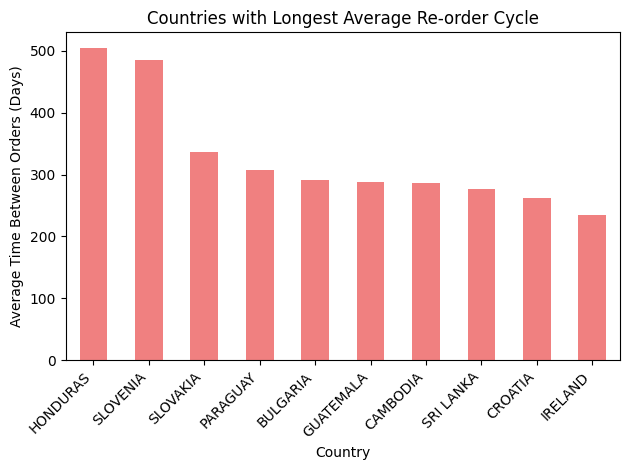

In [206]:
# 19) Lead Time and Re-order Cycles (for recurring countries)
# Sort records by country/date to preserve chronology, then compute reorder gaps.
df_sorted = df2.sort_values(['Final Country', 'Invoice Date']).copy()
df_sorted['Days_Since_Last_Order'] = df_sorted.groupby('Final Country')['Invoice Date'].diff().dt.days
avg_cycle = df_sorted.groupby('Final Country')['Days_Since_Last_Order'].mean().nlargest(10)
# Visualize the countries with the longest average reorder cycle.
# Higher bars imply lower ordering frequency (slower replenishment cadence).
ax = avg_cycle.plot(kind='bar', color='lightcoral')
ax.set_title('Countries with Longest Average Re-order Cycle')
ax.set_xlabel('Country')
ax.set_ylabel('Average Time Between Orders (Days)')
ax.yaxis.set_major_formatter(FuncFormatter(integer_with_commas))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


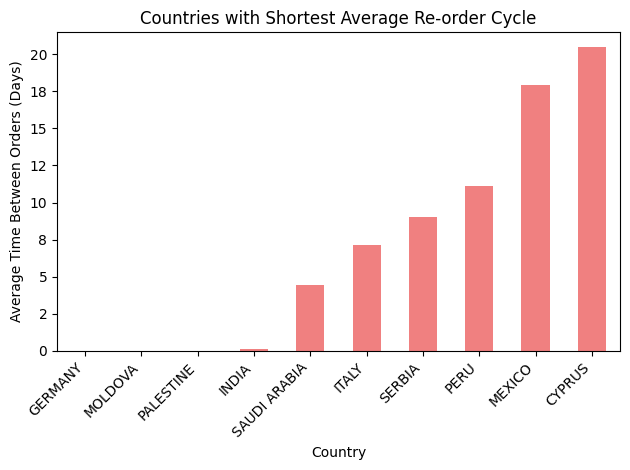

In [208]:
# 12 B
# Also inspect the opposite side: countries with shortest reorder cycle.
# These usually represent fast-moving or frequently replenished markets.
avg_cycle2 = df_sorted.groupby('Final Country')['Days_Since_Last_Order'].mean().nsmallest(10)
# Plot fastest reorder-cycle countries for easier comparison.
# Lower average days = more frequent repeat orders.
ax = avg_cycle2.plot(kind='bar', color='lightcoral')
ax.set_title('Countries with Shortest Average Re-order Cycle')
ax.set_xlabel('Country')
ax.set_ylabel('Average Time Between Orders (Days)')
ax.yaxis.set_major_formatter(FuncFormatter(integer_with_commas))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



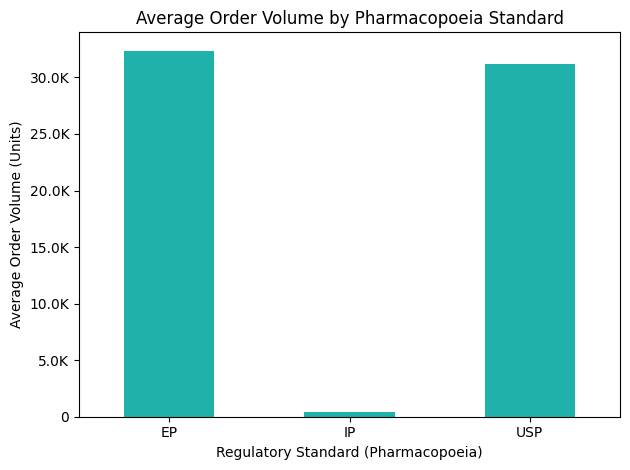

In [204]:
# 20) Standard Compliance Cost Analysis (logistics proxy)
# Mean order quantity by pharmacopoeia standard can indicate batch-size behavior.
compliance_vol = df2.groupby('Pharmacopoeia')['Total Qty'].mean()
# Visual comparison of average batch sizes by standard.
# Useful to check whether some standards are linked to consistently larger shipments.
ax = compliance_vol.plot(kind='bar', color='lightseagreen')
ax.set_title('Average Order Volume by Pharmacopoeia Standard')
ax.set_xlabel('Regulatory Standard (Pharmacopoeia)')
ax.set_ylabel('Average Order Volume (Units)')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



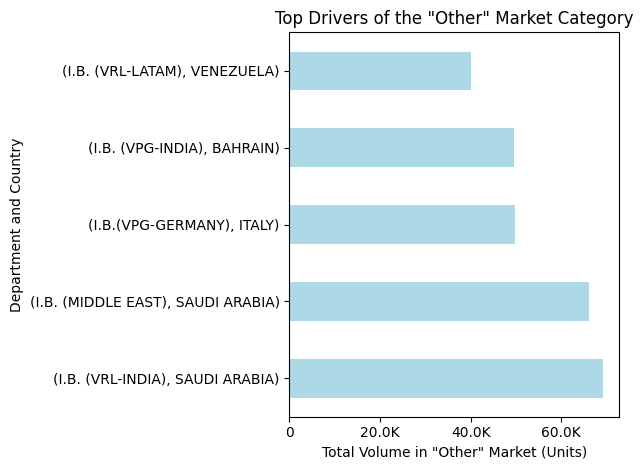

In [205]:
# 21) "Other" Market Investigation
# Drill down into the Market == 'Other' bucket and rank top contributors.
other_market = df2[df2['Market'] == 'Other'].groupby(['Department', 'Final Country'])['Total Qty'].sum().nlargest(5)
# Plot the top department-country drivers behind the 'Other' market category.
ax = other_market.plot(kind='barh', color='lightblue')
ax.set_title('Top Drivers of the "Other" Market Category')
ax.set_xlabel('Total Volume in "Other" Market (Units)')
ax.set_ylabel('Department and Country')
ax.xaxis.set_major_formatter(FuncFormatter(human_readable_number))
plt.tight_layout()
plt.show()


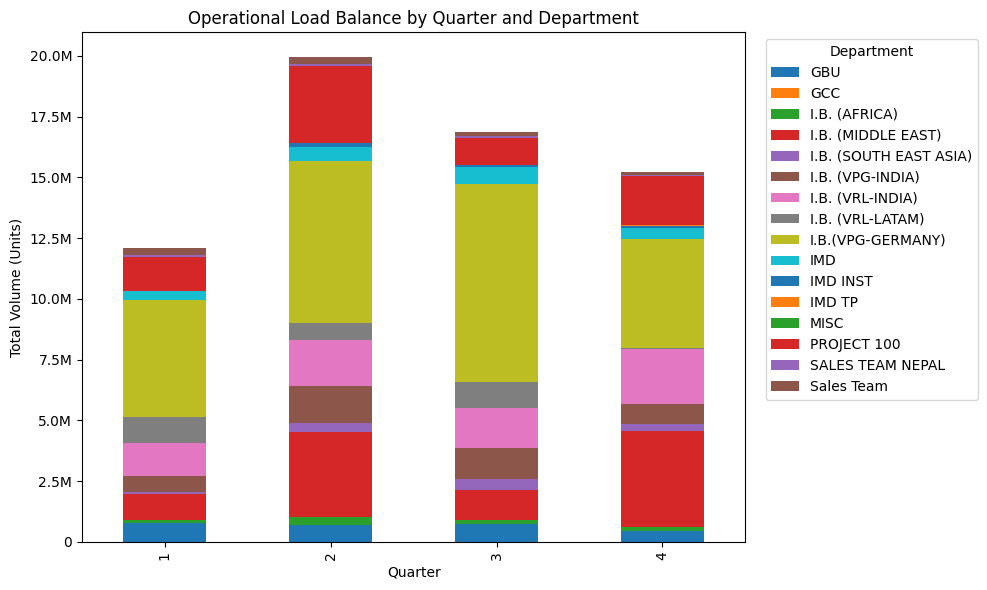

In [182]:
# 22) Operational Load Balance per Quarter
# Build a quarter x department table and render stacked bars.
# This reveals how workload share is distributed across teams each quarter.
load_balance = df2.pivot_table(index='Quarter', columns='Department', values='Total Qty', aggfunc='sum').fillna(0)
ax = load_balance.plot(kind='bar', stacked=True, figsize=(10,6), title='Operational Load Balance by Quarter and Department')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Volume (Units)')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
ax.legend(title='Department', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Advanced Insights for Business Teams
This section translates the raw transaction data into easy-to-understand business insights.
Each block uses plain names, clear headings, and readable charts so non-technical users can interpret decisions quickly.


In [183]:
# Shared setup for advanced insights.
# This block ensures dates are clean and gives us current reporting years.
advanced_df = df2.copy()
advanced_df['Invoice Date'] = pd.to_datetime(advanced_df['Invoice Date'], errors='coerce')
advanced_df = advanced_df.dropna(subset=['Invoice Date'])
advanced_df['Month Name'] = advanced_df['Invoice Date'].dt.strftime('%b')
advanced_df['Month Number'] = advanced_df['Invoice Date'].dt.month
latest_financial_year = int(advanced_df['Financial Year'].max())
previous_financial_year = latest_financial_year - 1

print('Advanced insight setup complete.')
print(f'Latest year in file: FY{latest_financial_year}')
print(f'Previous year used for comparison: FY{previous_financial_year}')


Advanced insight setup complete.
Latest year in file: FY2025
Previous year used for comparison: FY2024


### 23) What Is Driving the Year-to-Year Volume Change?
This shows which countries contributed most to the latest annual drop or increase.


Top countries reducing total volume (latest year vs previous year):
Final Country
MEXICO      -1024000
ITALY        -906986
PERU         -381310
UK           -357684
CYPRUS       -349350
VENEZUELA    -160000
THAILAND     -150000
BAHRAIN      -114500
LIBYA         -73996
COLOMBIA      -60000
dtype: int64
Top countries increasing total volume (latest year vs previous year):
Final Country
SAUDI ARABIA    562483
IRAQ            350055
INDIA           318100
HUNGARY         207428
FRANCE          169602
GERMANY         101108
UKRAINE          98300
TANZANIA         97000
SUDAN            65000
QATAR            63250
dtype: int64


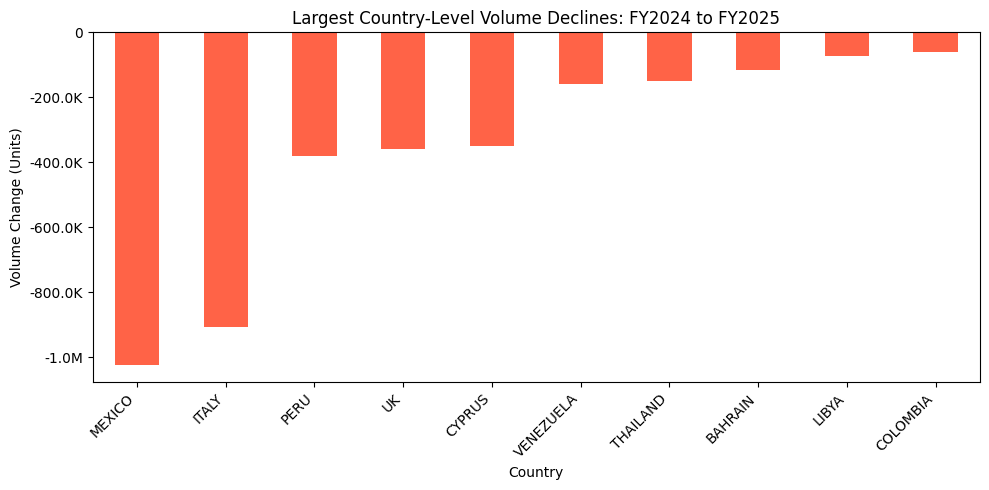

In [ ]:
# Compare country volume between latest year and previous year.
country_volume_by_year = advanced_df.groupby(['Financial Year', 'Final Country'])['Total Qty'].sum().unstack(fill_value=0)

if latest_financial_year in country_volume_by_year.index and previous_financial_year in country_volume_by_year.index:
    country_change = (country_volume_by_year.loc[latest_financial_year] - country_volume_by_year.loc[previous_financial_year]).sort_values()

    top_country_declines = country_change.head(10)
    top_country_growth = country_change.tail(10).sort_values(ascending=False)

    print('Top countries reducing total volume (latest year vs previous year):')
    print(top_country_declines)
    print('Top countries increasing total volume (latest year vs previous year):')
    print(top_country_growth)

    ax = top_country_declines.plot(kind='bar', color='tomato', figsize=(10, 5))
    ax.set_title(f'Largest Country-Level Volume Declines: FY{previous_financial_year} to FY{latest_financial_year}')
    ax.set_xlabel('Country')
    ax.set_ylabel('Volume Change (Units)')
    ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough yearly data to compute country-level year-over-year change.')


### 24) How Concentrated Is the Business?
If too much volume sits in a small number of countries, the business is more exposed to shocks.


Concentration trend by financial year:
                Top 3 Country Share (%)  HHI (0 to 10,000)
Financial Year                                            
2021                              61.44            1717.45
2022                              68.05            1824.09
2023                              64.36            1595.40
2024                              51.50            1356.28
2025                              57.60            1296.69


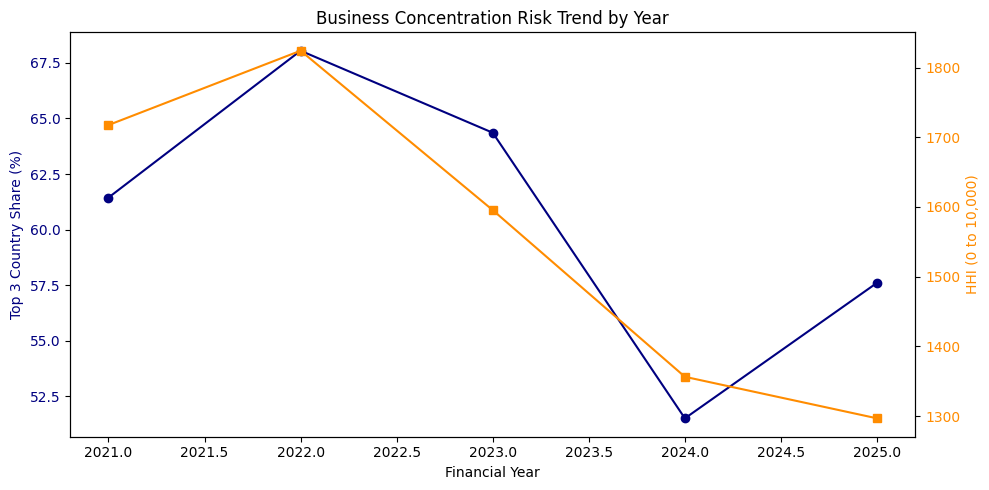

In [185]:
# Concentration metrics by financial year.
# Top 3 Share: % of annual volume from the 3 biggest countries.
# HHI: Concentration index (higher means more concentration risk).
country_year_table = advanced_df.groupby(['Financial Year', 'Final Country'])['Total Qty'].sum().unstack(fill_value=0)
country_share_table = country_year_table.div(country_year_table.sum(axis=1), axis=0)

concentration_over_time = pd.DataFrame({
    'Top 3 Country Share (%)': country_share_table.apply(lambda row: row.nlargest(3).sum() * 100, axis=1),
    'HHI (0 to 10,000)': country_share_table.apply(lambda row: (row.pow(2).sum()) * 10_000, axis=1),
}).sort_index()

print('Concentration trend by financial year:')
print(concentration_over_time.round(2))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(concentration_over_time.index, concentration_over_time['Top 3 Country Share (%)'], marker='o', color='navy', label='Top 3 Country Share (%)')
ax1.set_xlabel('Financial Year')
ax1.set_ylabel('Top 3 Country Share (%)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')

ax2 = ax1.twinx()
ax2.plot(concentration_over_time.index, concentration_over_time['HHI (0 to 10,000)'], marker='s', color='darkorange', label='HHI (0 to 10,000)')
ax2.set_ylabel('HHI (0 to 10,000)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Business Concentration Risk Trend by Year')
fig.tight_layout()
plt.show()


### 25) Which Months Are Usually Strong or Weak?
A monthly heatmap helps planning teams prepare inventory and operations before peak periods.


Top 3 months by total volume across all years:
Month Name
Sep    10941128
Dec     8657688
Mar     7221491
Name: Total Qty, dtype: int64


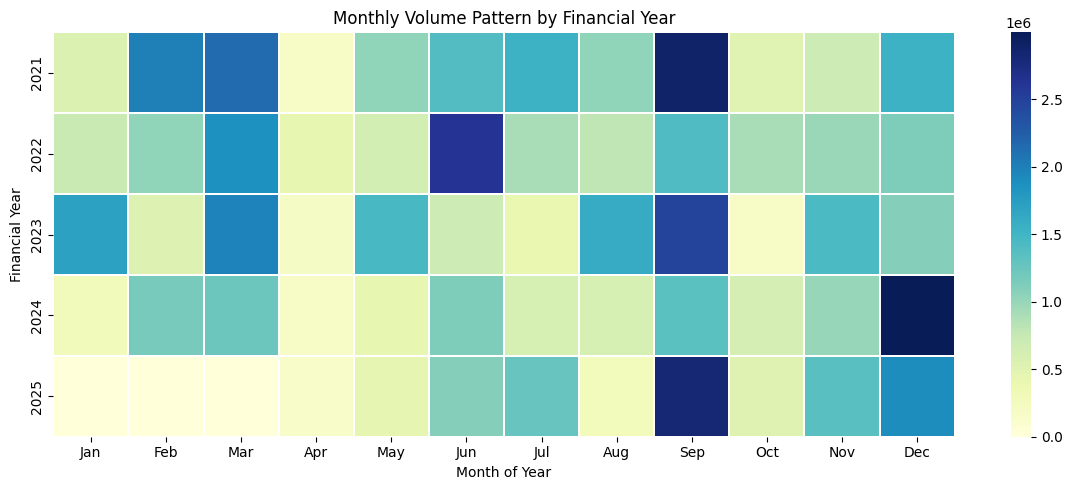

In [186]:
# Build month-by-year heatmap for total volume.
monthly_volume = advanced_df.groupby(['Financial Year', 'Month Number'])['Total Qty'].sum().reset_index()
heatmap_volume = monthly_volume.pivot(index='Financial Year', columns='Month Number', values='Total Qty').fillna(0)
heatmap_volume = heatmap_volume.reindex(columns=range(1, 13), fill_value=0)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

top_months = advanced_df.groupby('Month Name')['Total Qty'].sum().sort_values(ascending=False).head(3)
print('Top 3 months by total volume across all years:')
print(top_months)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_volume, cmap='YlGnBu', linewidths=0.3)
plt.title('Monthly Volume Pattern by Financial Year')
plt.xlabel('Month of Year')
plt.ylabel('Financial Year')
plt.xticks(ticks=[x + 0.5 for x in range(12)], labels=month_labels, rotation=0)
plt.tight_layout()
plt.show()


### 26) Is Channel Mix Shifting Between Tender, Private, and Other?
This shows whether the business model is changing over time.


Market mix by year (share %):
Market          Other  Private  Tender
Financial Year                        
2021             0.33    32.55   67.12
2022             0.40    30.92   68.68
2023             0.50    43.23   56.27
2024             1.52    33.25   65.23
2025             0.24    33.20   66.56


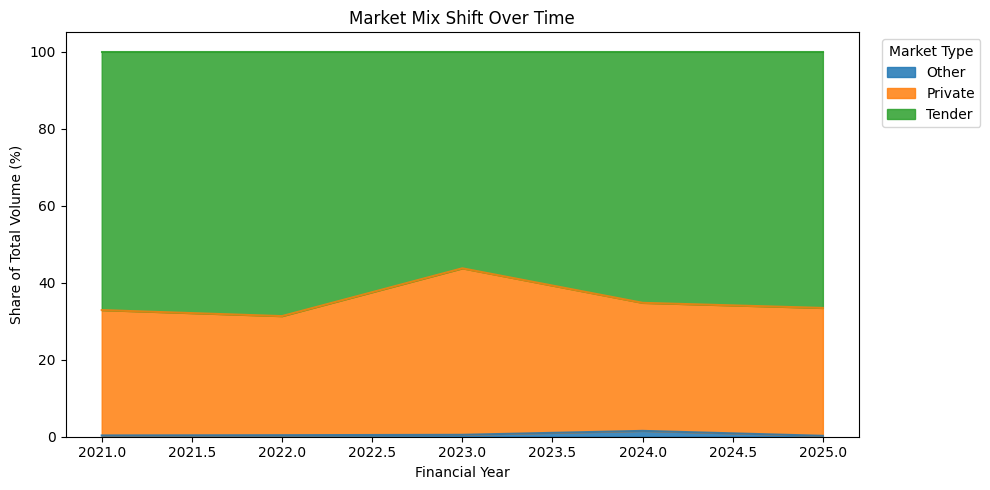

In [187]:
# Convert market volumes to percentages for each financial year.
market_volume_by_year = advanced_df.groupby(['Financial Year', 'Market'])['Total Qty'].sum().unstack(fill_value=0)
market_share_by_year = market_volume_by_year.div(market_volume_by_year.sum(axis=1), axis=0) * 100

print('Market mix by year (share %):')
print(market_share_by_year.round(2))

ax = market_share_by_year.plot(kind='area', stacked=True, figsize=(10, 5), alpha=0.85)
ax.set_title('Market Mix Shift Over Time')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Share of Total Volume (%)')
ax.legend(title='Market Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 27) Are New Markets Actually Sticking?
A market is more valuable when it places follow-up orders after first entry.


Recent new-market entries (last 2 financial years):
        Country  First Active Year  Repeat in Next Year
3      BULGARIA               2024                 True
4      CAMBODIA               2024                 True
10  EI SALVADOR               2024                False
11     ESWATINI               2024                 True
32    LITHUANIA               2024                False
41    PALESTINE               2024                False
58     THAILAND               2024                 True
15      GERMANY               2025                False
19      HUNGARY               2025                False
30      LESOTHO               2025                False
34        MALTA               2025                False
36      MOLDOVA               2025                False
50       SERBIA               2025                False
Repeat-order rate for recent new markets: 30.8%


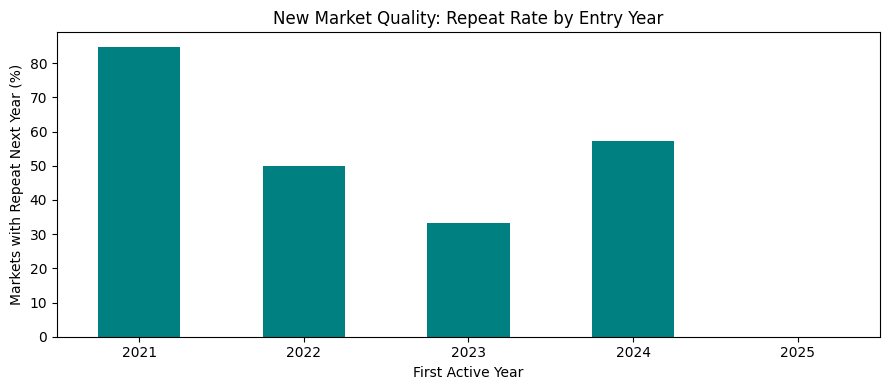

In [188]:
# Identify each country's first active year and whether it repeated next year.
country_presence = advanced_df.groupby(['Final Country', 'Financial Year']).size().unstack(fill_value=0)
first_active_year = country_presence.apply(lambda row: row[row > 0].index.min(), axis=1)

market_entry_quality = pd.DataFrame({'First Active Year': first_active_year})
market_entry_quality.index.name = 'Country'
market_entry_quality = market_entry_quality.reset_index()

market_entry_quality['Repeat in Next Year'] = market_entry_quality.apply(
    lambda row: country_presence.loc[row['Country']].get(row['First Active Year'] + 1, 0) > 0,
    axis=1,
)

recent_entries = market_entry_quality[market_entry_quality['First Active Year'] >= (latest_financial_year - 1)]
repeat_rate = recent_entries['Repeat in Next Year'].mean() * 100 if len(recent_entries) > 0 else float('nan')

print('Recent new-market entries (last 2 financial years):')
print(recent_entries.sort_values(['First Active Year', 'Country']))
print(f'Repeat-order rate for recent new markets: {repeat_rate:.1f}%')

entry_summary = market_entry_quality.groupby('First Active Year')['Repeat in Next Year'].mean().mul(100)
ax = entry_summary.plot(kind='bar', color='teal', figsize=(9, 4))
ax.set_title('New Market Quality: Repeat Rate by Entry Year')
ax.set_xlabel('First Active Year')
ax.set_ylabel('Markets with Repeat Next Year (%)')
ax.yaxis.set_major_formatter(FuncFormatter(integer_with_commas))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 28) Which Countries Are Stable vs Volatile in Re-order Pattern?
This helps separate dependable markets from unpredictable ones.


Country stability segment counts:
Business Segment
Frequent but Unstable      28
Infrequent and Unstable    19
Name: count, dtype: int64


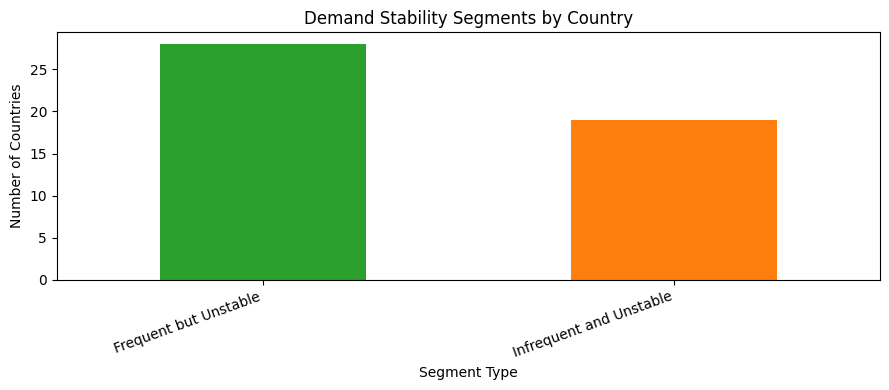

In [189]:
# Create reorder-cycle statistics per country.
country_order_flow = advanced_df.sort_values(['Final Country', 'Invoice Date']).copy()
country_order_flow['Days Between Orders'] = country_order_flow.groupby('Final Country')['Invoice Date'].diff().dt.days

reorder_stats = country_order_flow.groupby('Final Country')['Days Between Orders'].agg(
    Number_of_Intervals='count',
    Average_Days='mean',
    Median_Days='median',
    Std_Days='std',
).dropna()

reorder_stats = reorder_stats[reorder_stats['Number_of_Intervals'] >= 5].copy()
reorder_stats['Volatility_Ratio'] = reorder_stats['Std_Days'] / reorder_stats['Average_Days']


def reorder_segment(row):
    if row['Average_Days'] <= 90 and row['Volatility_Ratio'] <= 0.5:
        return 'Stable and Frequent'
    if row['Average_Days'] <= 90 and row['Volatility_Ratio'] > 0.5:
        return 'Frequent but Unstable'
    if row['Average_Days'] > 90 and row['Volatility_Ratio'] <= 0.5:
        return 'Predictable but Infrequent'
    return 'Infrequent and Unstable'


reorder_stats['Business Segment'] = reorder_stats.apply(reorder_segment, axis=1)
segment_count = reorder_stats['Business Segment'].value_counts()

print('Country stability segment counts:')
print(segment_count)

ax = segment_count.plot(kind='bar', color=['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728'], figsize=(9, 4))
ax.set_title('Demand Stability Segments by Country')
ax.set_xlabel('Segment Type')
ax.set_ylabel('Number of Countries')
ax.yaxis.set_major_formatter(FuncFormatter(integer_with_commas))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### 29) How Dependent Are We on March 31 Year-End Pushes?
This quantifies how much of annual volume is concentrated on the financial year closing day.


Share of yearly volume shipped on 31-Mar:
Financial Year
2021    1.72
2022    6.20
2023    8.21
2024    2.70
2025    0.00
Name: Total Qty, dtype: float64


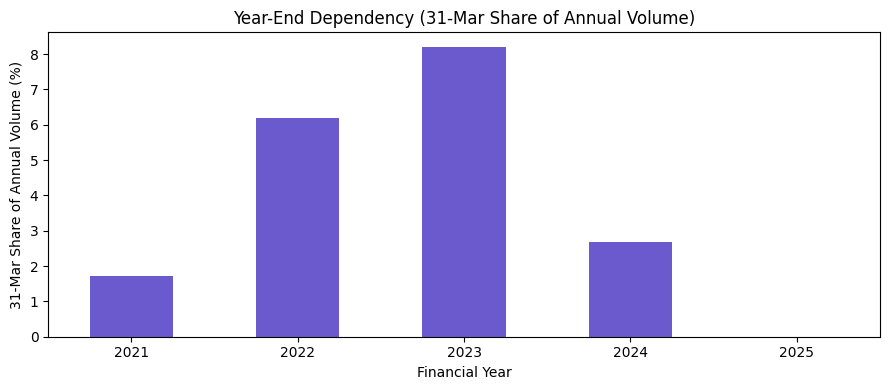

Top departments contributing to 31-Mar push in FY2025:
Series([], Name: Total Qty, dtype: int64)


In [190]:
# Compute year-end dependency ratio.
year_end_flag = advanced_df['Invoice Date'].dt.strftime('%d-%b') == '31-Mar'
year_end_volume_by_year = advanced_df[year_end_flag].groupby('Financial Year')['Total Qty'].sum()
annual_volume_by_year = advanced_df.groupby('Financial Year')['Total Qty'].sum()

year_end_dependency = (year_end_volume_by_year / annual_volume_by_year * 100).fillna(0).sort_index()

print('Share of yearly volume shipped on 31-Mar:')
print(year_end_dependency.round(2))

ax = year_end_dependency.plot(kind='bar', color='slateblue', figsize=(9, 4))
ax.set_title('Year-End Dependency (31-Mar Share of Annual Volume)')
ax.set_xlabel('Financial Year')
ax.set_ylabel('31-Mar Share of Annual Volume (%)')
ax.yaxis.set_major_formatter(FuncFormatter(integer_with_commas))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

latest_year_end_by_department = advanced_df[(advanced_df['Financial Year'] == latest_financial_year) & year_end_flag].groupby('Department')['Total Qty'].sum().nlargest(10)
print(f'Top departments contributing to 31-Mar push in FY{latest_financial_year}:')
print(latest_year_end_by_department)


### 30) Is API Consumption Efficiency Staying Stable?
Tracks monthly API usage ratio against the expected benchmark (around 1.41).


Recent monthly API utilization ratio (last 6 months available):
Invoice Date
2025-07-31    1.41
2025-08-31    1.41
2025-09-30    1.41
2025-10-31    1.41
2025-11-30    1.41
2025-12-31    1.41
Freq: ME, Name: API Use Ratio, dtype: float64


/var/folders/2h/9t6yflpn4970wwb1dkydnfp80000gn/T/ipykernel_1980/2138888534.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_api_ratio = advanced_df.set_index('Invoice Date')['API Use Ratio'].resample('M').mean().dropna()


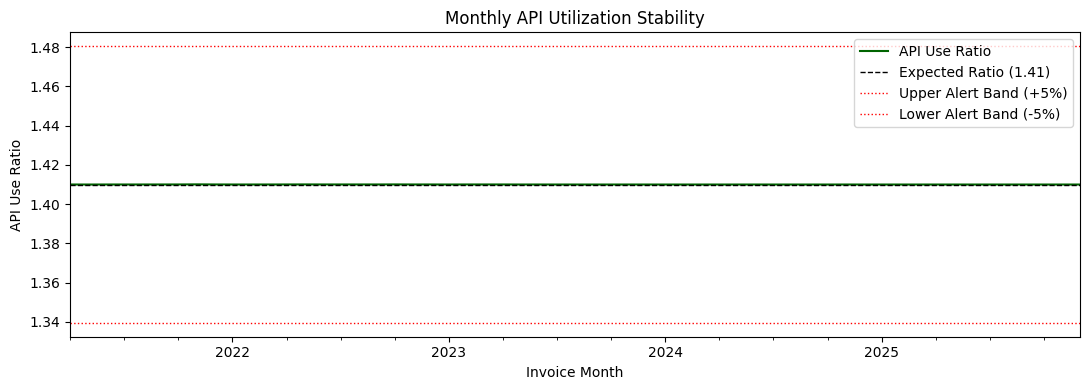

In [191]:
# Monthly API utilization monitoring.
advanced_df['API Use Ratio'] = (advanced_df['API Requirement in KG'] * 1_000_000) / (advanced_df['Total Qty'] * advanced_df['Strength In MG'])
advanced_df.loc[~np.isfinite(advanced_df['API Use Ratio']), 'API Use Ratio'] = np.nan

monthly_api_ratio = advanced_df.set_index('Invoice Date')['API Use Ratio'].resample('M').mean().dropna()
expected_ratio = 1.41
upper_limit = expected_ratio * 1.05
lower_limit = expected_ratio * 0.95

print('Recent monthly API utilization ratio (last 6 months available):')
print(monthly_api_ratio.tail(6).round(4))

ax = monthly_api_ratio.plot(figsize=(11, 4), color='darkgreen')
ax.axhline(expected_ratio, color='black', linestyle='--', linewidth=1, label='Expected Ratio (1.41)')
ax.axhline(upper_limit, color='red', linestyle=':', linewidth=1, label='Upper Alert Band (+5%)')
ax.axhline(lower_limit, color='red', linestyle=':', linewidth=1, label='Lower Alert Band (-5%)')
ax.set_title('Monthly API Utilization Stability')
ax.set_xlabel('Invoice Month')
ax.set_ylabel('API Use Ratio')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


### 31) What Is Behind the Largest Transactions?
Outlier analysis helps identify whether large orders are concentrated in specific departments or channels.


Outlier cutoff used (99th percentile): 50,946 units
Department share inside large transactions (%):
Department
I.B.(VPG-GERMANY)         35.61
PROJECT 100               30.97
I.B. (VRL-INDIA)          18.23
I.B. (VPG-INDIA)           4.16
I.B. (VRL-LATAM)           4.11
I.B. (SOUTH EAST ASIA)     3.04
I.B. (MIDDLE EAST)         1.72
IMD                        1.04
I.B. (AFRICA)              0.66
IMD INST                   0.27
Name: Total Qty, dtype: float64
Market share inside large transactions (%):
Market
Tender     67.62
Private    32.38
Name: Total Qty, dtype: float64


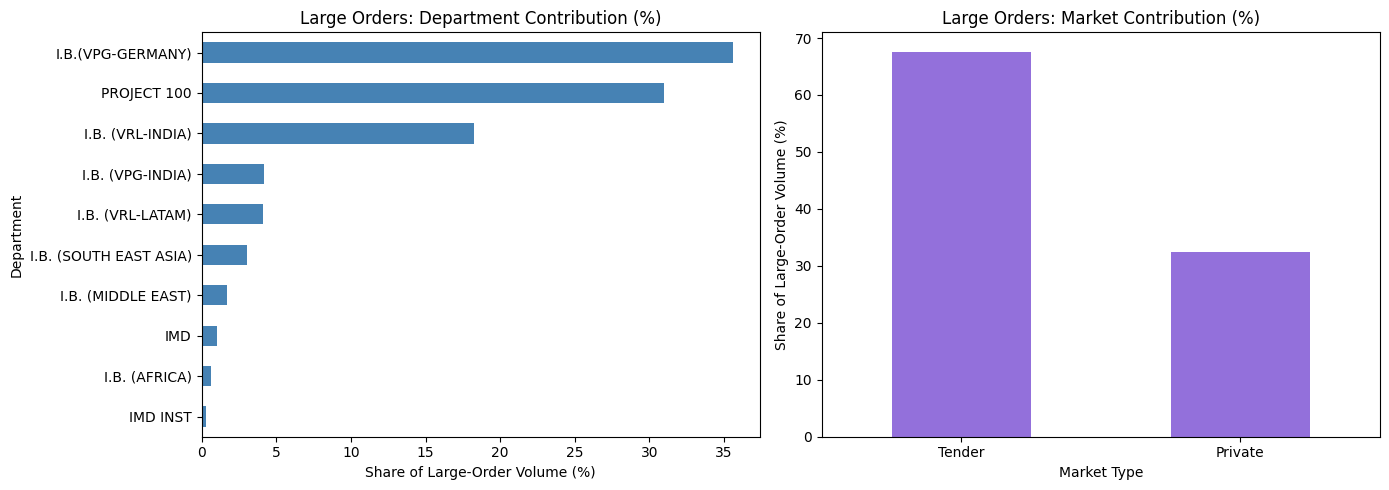

In [192]:
# Focus on top 1% transaction sizes.
outlier_cutoff = advanced_df['Total Qty'].quantile(0.99)
large_orders = advanced_df[advanced_df['Total Qty'] >= outlier_cutoff].copy()

large_order_dept_share = (large_orders.groupby('Department')['Total Qty'].sum() / large_orders['Total Qty'].sum() * 100).sort_values(ascending=False).head(10)
large_order_market_share = (large_orders.groupby('Market')['Total Qty'].sum() / large_orders['Total Qty'].sum() * 100).sort_values(ascending=False)

print(f'Outlier cutoff used (99th percentile): {outlier_cutoff:,.0f} units')
print('Department share inside large transactions (%):')
print(large_order_dept_share.round(2))
print('Market share inside large transactions (%):')
print(large_order_market_share.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
large_order_dept_share.sort_values().plot(kind='barh', color='steelblue', ax=axes[0])
axes[0].set_title('Large Orders: Department Contribution (%)')
axes[0].set_xlabel('Share of Large-Order Volume (%)')
axes[0].set_ylabel('Department')

large_order_market_share.plot(kind='bar', color='mediumpurple', ax=axes[1])
axes[1].set_title('Large Orders: Market Contribution (%)')
axes[1].set_xlabel('Market Type')
axes[1].set_ylabel('Share of Large-Order Volume (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 32) Country Opportunity Matrix: Where to Defend vs Grow?
Combines current scale and recent growth to prioritize commercial focus.


Priority segment count:
Priority Segment
Defend and Grow        9
Selective / Monitor    8
Defend Core            7
Build Aggressively     7
Name: count, dtype: int64


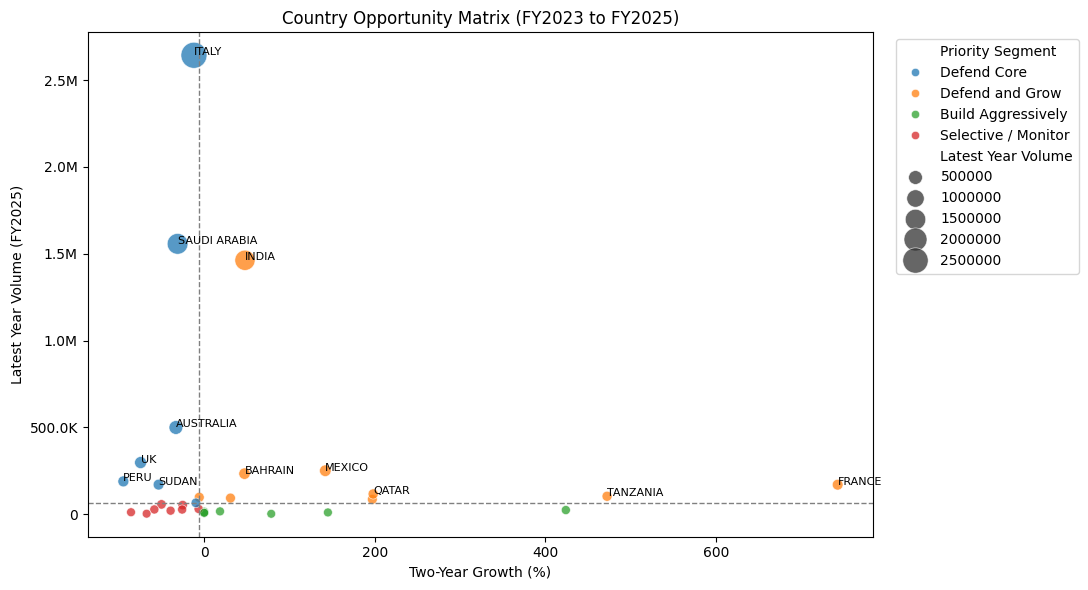

In [193]:
# Build a country matrix using latest volume and 2-year growth.
start_year_for_growth = latest_financial_year - 2
country_year_volume = advanced_df.groupby(['Final Country', 'Financial Year'])['Total Qty'].sum().unstack(fill_value=0)

if start_year_for_growth in country_year_volume.columns and latest_financial_year in country_year_volume.columns:
    matrix_data = country_year_volume[(country_year_volume[start_year_for_growth] > 0) & (country_year_volume[latest_financial_year] > 0)].copy()
    matrix_data['Latest Year Volume'] = matrix_data[latest_financial_year]
    matrix_data['Two Year Growth (%)'] = ((matrix_data[latest_financial_year] / matrix_data[start_year_for_growth]) - 1) * 100

    volume_split = matrix_data['Latest Year Volume'].median()
    growth_split = matrix_data['Two Year Growth (%)'].median()

    def classify_priority(row):
        if row['Latest Year Volume'] >= volume_split and row['Two Year Growth (%)'] >= growth_split:
            return 'Defend and Grow'
        if row['Latest Year Volume'] >= volume_split and row['Two Year Growth (%)'] < growth_split:
            return 'Defend Core'
        if row['Latest Year Volume'] < volume_split and row['Two Year Growth (%)'] >= growth_split:
            return 'Build Aggressively'
        return 'Selective / Monitor'

    matrix_data['Priority Segment'] = matrix_data.apply(classify_priority, axis=1)

    print('Priority segment count:')
    print(matrix_data['Priority Segment'].value_counts())

    plt.figure(figsize=(11, 6))
    ax = sns.scatterplot(
        data=matrix_data,
        x='Two Year Growth (%)',
        y='Latest Year Volume',
        hue='Priority Segment',
        size='Latest Year Volume',
        sizes=(40, 350),
        alpha=0.75,
    )

    plt.axvline(growth_split, color='gray', linestyle='--', linewidth=1)
    plt.axhline(volume_split, color='gray', linestyle='--', linewidth=1)

    top_label_countries = matrix_data.nlargest(12, 'Latest Year Volume')
    for country_name, row in top_label_countries.iterrows():
        plt.text(row['Two Year Growth (%)'], row['Latest Year Volume'], country_name, fontsize=8)

    ax.set_title(f'Country Opportunity Matrix (FY{start_year_for_growth} to FY{latest_financial_year})')
    ax.set_xlabel('Two-Year Growth (%)')
    ax.set_ylabel(f'Latest Year Volume (FY{latest_financial_year})')
    ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough year coverage to build the 2-year opportunity matrix.')


### Suggested Business Use
- Use Insights 1, 2, and 10 for country-level commercial planning.
- Use Insights 3 and 7 for production and dispatch planning.
- Use Insights 6 and 8 for operational stability and quality reviews.
- Use Insights 4, 5, and 9 for channel strategy and new-market effectiveness.


## Detailed Comparison Section (Year, Quarter, Department, SKU, Strength)
This section gives a more specific view of the data by comparing combinations of dimensions, not only overall totals.
It is designed to answer: what changed, where it changed, and which product or team is driving that change.


In [194]:
# Setup for detailed comparisons.
# This block is written so the section can run even if you start from here.
if 'advanced_df' in globals():
    compare_df = advanced_df.copy()
elif 'df2' in globals():
    compare_df = df2.copy()
elif 'df' in globals():
    compare_df = df.copy()
else:
    raise NameError('No base dataframe found. Please run the data loading cells first.')

compare_df['Invoice Date'] = pd.to_datetime(compare_df['Invoice Date'], errors='coerce')
compare_df = compare_df.dropna(subset=['Invoice Date']).copy()
compare_df['Financial Year'] = compare_df['Financial Year'].astype(int)
compare_df['Quarter'] = compare_df['Quarter'].astype(int)
compare_df['Strength Label'] = compare_df['Strength In MG'].apply(lambda x: f"{int(x)} mg" if pd.notna(x) else 'Unknown Strength')
compare_df['SKU Name'] = compare_df['Generic Name'].astype(str).str.strip() + ' - ' + compare_df['Strength Label']

if 'human_readable_number' not in globals():
    def human_readable_number(value, _):
        abs_value = abs(value)
        if abs_value >= 1_000_000_000:
            return f'{value/1_000_000_000:.1f}B'
        if abs_value >= 1_000_000:
            return f'{value/1_000_000:.1f}M'
        if abs_value >= 1_000:
            return f'{value/1_000:.1f}K'
        return f'{value:,.0f}'

if 'integer_with_commas' not in globals():
    def integer_with_commas(value, _):
        return f'{value:,.0f}'

latest_year_cmp = int(compare_df['Financial Year'].max())
previous_year_cmp = latest_year_cmp - 1

print('Detailed comparison setup complete.')
print(f'Latest financial year available: FY{latest_year_cmp}')
print(f'Previous financial year for comparison: FY{previous_year_cmp}')
print('Unique departments:', compare_df['Department'].nunique())
print('Unique SKU combinations (name + strength):', compare_df['SKU Name'].nunique())


Detailed comparison setup complete.
Latest financial year available: FY2025
Previous financial year for comparison: FY2024
Unique departments: 16
Unique SKU combinations (name + strength): 5


### 33) Year vs Quarter Comparison
Shows how each quarter performs inside each financial year.


Volume by Year and Quarter (Units):
Quarter               1        2        3        4
Financial Year                                    
2021            2614816  5464103  2738248  4700202
2022            3686463  3106652  3025982  3631285
2023            2363110  4502637  2704779  4207154
2024            1733534  2542665  4620380  2692846
2025            1697487  4357935  3775087        0


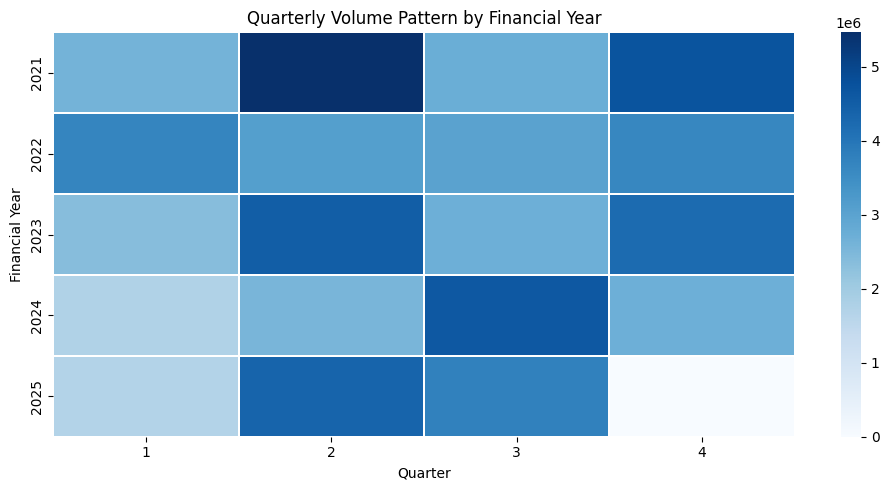

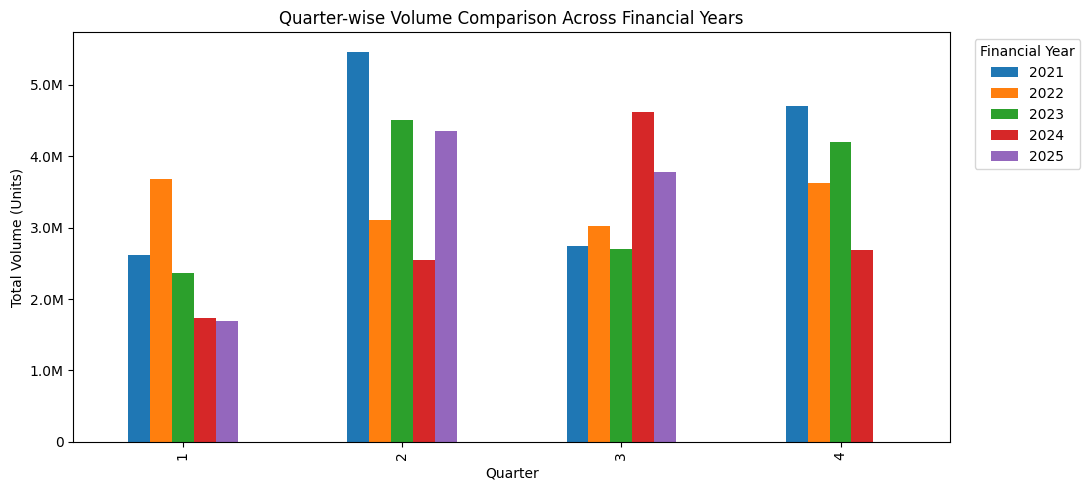

In [195]:
# Year-quarter comparison table.
year_quarter_volume = compare_df.groupby(['Financial Year', 'Quarter'])['Total Qty'].sum().unstack(fill_value=0)
year_quarter_volume = year_quarter_volume.reindex(columns=[1, 2, 3, 4], fill_value=0).sort_index()

print('Volume by Year and Quarter (Units):')
print(year_quarter_volume)

plt.figure(figsize=(10, 5))
sns.heatmap(year_quarter_volume, cmap='Blues', linewidths=0.3)
plt.title('Quarterly Volume Pattern by Financial Year')
plt.xlabel('Quarter')
plt.ylabel('Financial Year')
plt.tight_layout()
plt.show()

ax = year_quarter_volume.T.plot(kind='bar', figsize=(11, 5))
ax.set_title('Quarter-wise Volume Comparison Across Financial Years')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Volume (Units)')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
ax.legend(title='Financial Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 34) Quarter-by-Quarter Year-on-Year Change
Highlights exactly which quarter improved or dropped in the latest year.


Quarter-wise YoY change for FY2025 (vs FY2024):
Quarter
1     -2.08
2     71.39
3    -18.29
4   -100.00
Name: 2025, dtype: float64


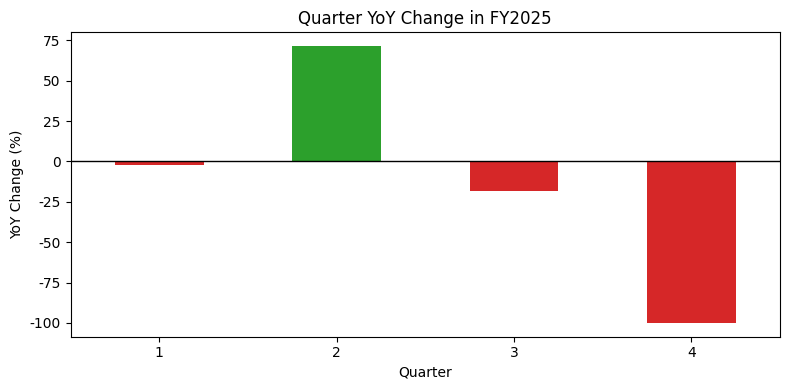

In [196]:
# Quarter-level year-on-year percentage change.
quarter_yoy_change = year_quarter_volume.pct_change() * 100

if latest_year_cmp in quarter_yoy_change.index:
    latest_quarter_change = quarter_yoy_change.loc[latest_year_cmp]
    print(f'Quarter-wise YoY change for FY{latest_year_cmp} (vs FY{previous_year_cmp}):')
    print(latest_quarter_change.round(2))

    bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in latest_quarter_change.fillna(0)]
    ax = latest_quarter_change.plot(kind='bar', color=bar_colors, figsize=(8, 4))
    ax.set_title(f'Quarter YoY Change in FY{latest_year_cmp}')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('YoY Change (%)')
    ax.axhline(0, color='black', linewidth=1)
    ax.yaxis.set_major_formatter(FuncFormatter(integer_with_commas))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough yearly data to calculate latest quarter-wise YoY change.')


### 35) Department Performance Across Years
Compares every department over time and shows top gainers/decliners in the latest year.


Top departments based on FY2025 volume:
Department      I.B.(VPG-GERMANY)  I.B. (MIDDLE EAST)  I.B. (VPG-INDIA)  \
Financial Year                                                            
2021                      4707250                   0            374069   
2022                      5991840                   0            546954   
2023                      4953536             6993998            766540   
2024                      4805077             1084420           1197907   
2025                      3621892             1685198           1432425   

Department         IMD     GBU  I.B. (VRL-LATAM)  I.B. (SOUTH EAST ASIA)  \
Financial Year                                                             
2021            599990  339905                 0                       0   
2022                 0  258976                 0                       0   
2023            308278  678665                 0                       0   
2024            406480  735914           2273650      

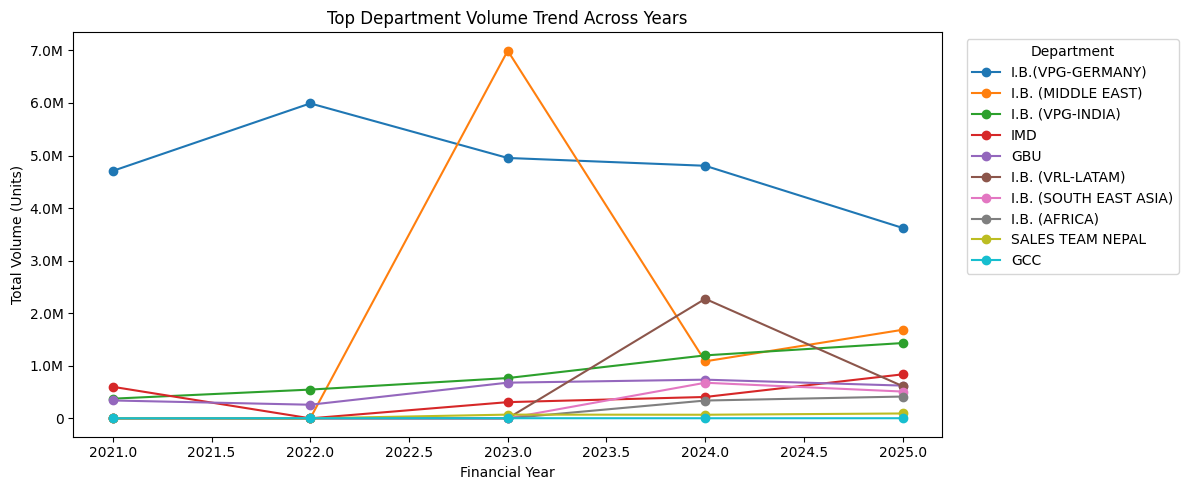

Department growth % from FY2024 to FY2025:
Department
IMD                       105.98
I.B. (MIDDLE EAST)         55.40
SALES TEAM NEPAL           35.38
GCC                        23.31
I.B. (AFRICA)              22.44
I.B. (VPG-INDIA)           19.58
GBU                       -15.36
I.B.(VPG-GERMANY)         -24.62
I.B. (SOUTH EAST ASIA)    -24.72
I.B. (VRL-LATAM)          -73.10
dtype: float64
Biggest department declines (%):
Department
MISC                     -100.00
I.B. (VRL-LATAM)          -73.10
I.B. (SOUTH EAST ASIA)    -24.72
I.B.(VPG-GERMANY)         -24.62
GBU                       -15.36
I.B. (VPG-INDIA)           19.58
I.B. (AFRICA)              22.44
GCC                        23.31
SALES TEAM NEPAL           35.38
I.B. (MIDDLE EAST)         55.40
dtype: float64


In [197]:
# Department-level yearly comparison.
department_year_volume = compare_df.groupby(['Department', 'Financial Year'])['Total Qty'].sum().unstack(fill_value=0)

if latest_year_cmp in department_year_volume.columns:
    top_departments_latest = department_year_volume[latest_year_cmp].sort_values(ascending=False).head(10).index
else:
    top_departments_latest = department_year_volume.sum(axis=1).sort_values(ascending=False).head(10).index

department_trend_top = department_year_volume.loc[top_departments_latest].T
print(f'Top departments based on FY{latest_year_cmp} volume:')
print(department_trend_top)

ax = department_trend_top.plot(marker='o', figsize=(12, 5))
ax.set_title('Top Department Volume Trend Across Years')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Total Volume (Units)')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
ax.legend(title='Department', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

if previous_year_cmp in department_year_volume.columns and latest_year_cmp in department_year_volume.columns:
    dept_growth_pct = ((department_year_volume[latest_year_cmp] - department_year_volume[previous_year_cmp]) /
                       department_year_volume[previous_year_cmp].replace(0, np.nan)) * 100
    dept_growth_pct = dept_growth_pct.replace([np.inf, -np.inf], np.nan).dropna()

    print(f'Department growth % from FY{previous_year_cmp} to FY{latest_year_cmp}:')
    print(dept_growth_pct.sort_values(ascending=False).head(10).round(2))
    print('Biggest department declines (%):')
    print(dept_growth_pct.sort_values().head(10).round(2))


### 36) Quarter + Department Comparison in Latest Year
Shows which department leads each quarter in the most recent year.


Top department in each quarter for FY2025:
Quarter
1    I.B. (MIDDLE EAST)
2     I.B.(VPG-GERMANY)
3     I.B.(VPG-GERMANY)
4                   GBU
dtype: object


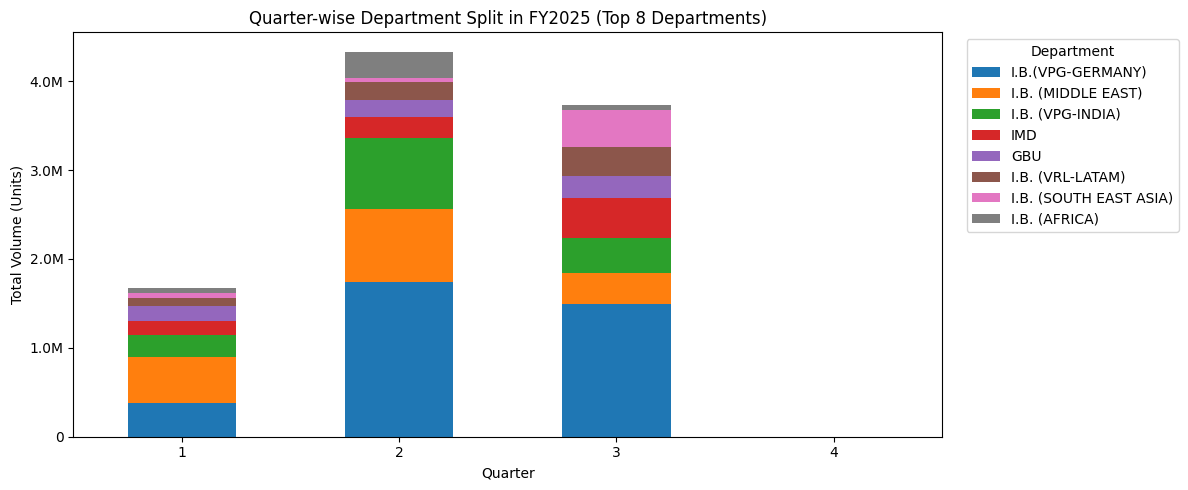

In [198]:
# Department-quarter split for latest year.
latest_year_data = compare_df[compare_df['Financial Year'] == latest_year_cmp].copy()
department_quarter_latest = latest_year_data.groupby(['Quarter', 'Department'])['Total Qty'].sum().unstack(fill_value=0)
department_quarter_latest = department_quarter_latest.reindex(index=[1, 2, 3, 4], fill_value=0)

quarter_top_department = department_quarter_latest.idxmax(axis=1)
print(f'Top department in each quarter for FY{latest_year_cmp}:')
print(quarter_top_department)

best_departments = latest_year_data.groupby('Department')['Total Qty'].sum().nlargest(8).index
display_table = department_quarter_latest[best_departments]

ax = display_table.plot(kind='bar', stacked=True, figsize=(12, 5))
ax.set_title(f'Quarter-wise Department Split in FY{latest_year_cmp} (Top 8 Departments)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Volume (Units)')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
ax.legend(title='Department', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 37) Strength Mix Comparison Across Years
Tracks whether the business is shifting between 500 mg, 1000 mg, 2000 mg, etc.


Strength mix share by year (%):
Financial Year   2021   2022   2023   2024   2025
Strength Label                                   
1000 mg         71.69  70.71  53.33  75.46  74.22
500 mg          27.59  28.56  45.69  23.71  24.96
125 mg           0.51   0.69   0.70   0.77   0.76
2000 mg          0.01   0.04   0.27   0.06   0.07
250 mg           0.20   0.00   0.00   0.00   0.00


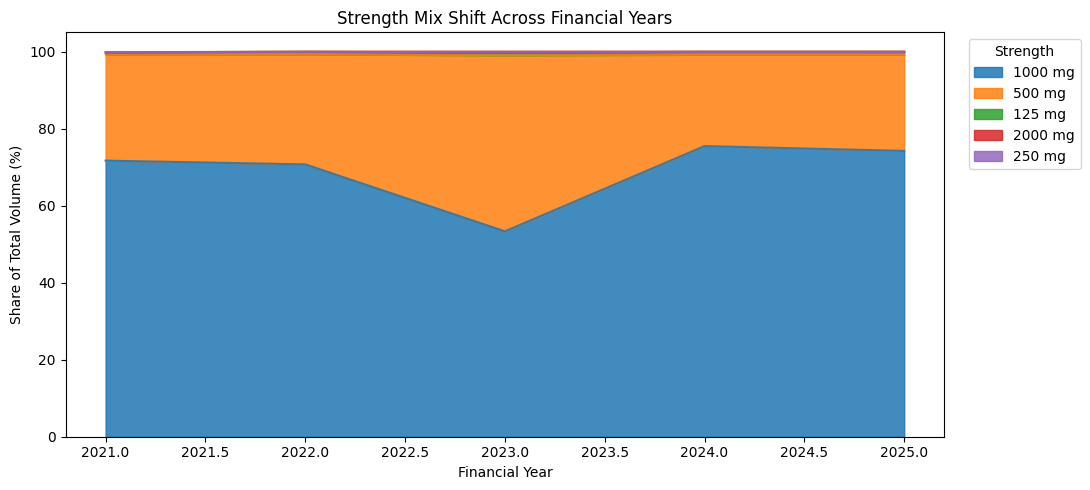

In [199]:
# Strength volume and share trend by year.
strength_year_volume = compare_df.groupby(['Strength Label', 'Financial Year'])['Total Qty'].sum().unstack(fill_value=0)
strength_order = compare_df.groupby('Strength Label')['Total Qty'].sum().sort_values(ascending=False).index
strength_year_volume = strength_year_volume.loc[strength_order]

strength_share_by_year = strength_year_volume.div(strength_year_volume.sum(axis=0), axis=1) * 100
print('Strength mix share by year (%):')
print(strength_share_by_year.round(2))

ax = strength_share_by_year.T.plot(kind='area', stacked=True, figsize=(11, 5), alpha=0.85)
ax.set_title('Strength Mix Shift Across Financial Years')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Share of Total Volume (%)')
ax.legend(title='Strength', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 38) Department vs Strength (Latest Year)
Identifies which departments are specialized in which strengths.


Department vs Strength table for FY2025 (top departments):
Strength Label          1000 mg  125 mg  2000 mg   500 mg
Department                                               
I.B.(VPG-GERMANY)       2372116       0     3106  1246670
I.B. (MIDDLE EAST)      1156145       0        0   529053
I.B. (VPG-INDIA)        1121415       0        0   311010
IMD                      737330       0        0    99937
GBU                      413240   74700     1180   133776
I.B. (VRL-LATAM)         546970       0        0    64690
I.B. (SOUTH EAST ASIA)   508740       0        0      968
I.B. (AFRICA)            368231       0        0    46474
SALES TEAM NEPAL          71600       0        0    21000
GCC                           0       0     2158        0


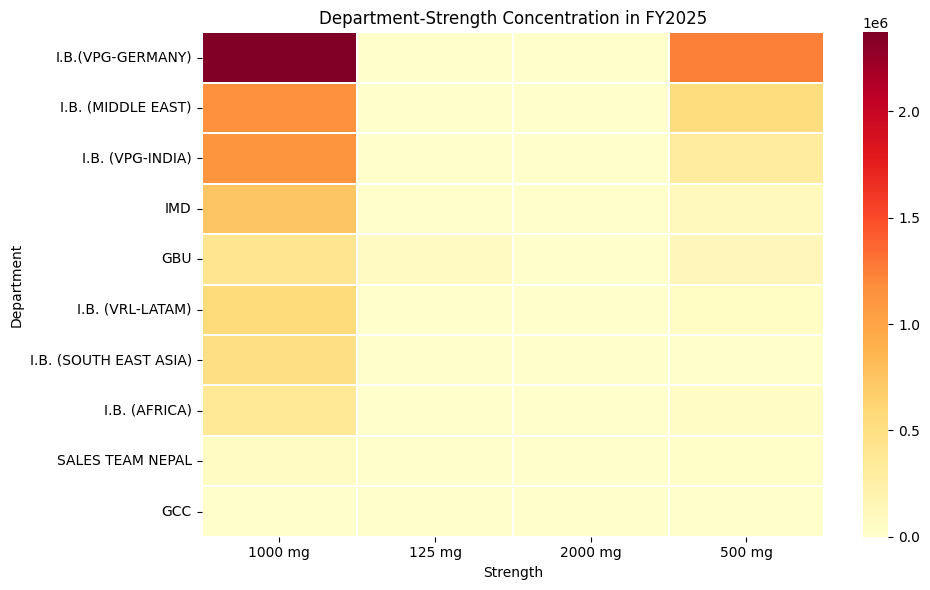

In [200]:
# Department-strength heatmap for latest year.
department_strength_latest = latest_year_data.groupby(['Department', 'Strength Label'])['Total Qty'].sum().unstack(fill_value=0)
top_departments_heatmap = latest_year_data.groupby('Department')['Total Qty'].sum().nlargest(12).index
heatmap_data = department_strength_latest.loc[top_departments_heatmap]

print(f'Department vs Strength table for FY{latest_year_cmp} (top departments):')
print(heatmap_data)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3)
plt.title(f'Department-Strength Concentration in FY{latest_year_cmp}')
plt.xlabel('Strength')
plt.ylabel('Department')
plt.tight_layout()
plt.show()


### 39) SKU Comparison Across Years (SKU = Generic Name + Strength)
Shows how major SKUs are changing over time.


Top SKU trend table (based on FY2025):
SKU Name        MEROPENEM - 1000 mg  MEROPENEM - 500 mg  MEROPENEM - 125 mg  \
Financial Year                                                                
2021                       11124555             4281953               78797   
2022                        9511246             3841284               92575   
2023                        7348277             6295193               96464   
2024                        8745792             2748267               88896   
2025                        7295787             2453578               74700   

SKU Name        MEROPENEM - 2000 mg  MEROPENEM - 250 mg  
Financial Year                                           
2021                           1000               31064  
2022                           4980                 297  
2023                          37746                   0  
2024                           6470                   0  
2025                           6444                   0  


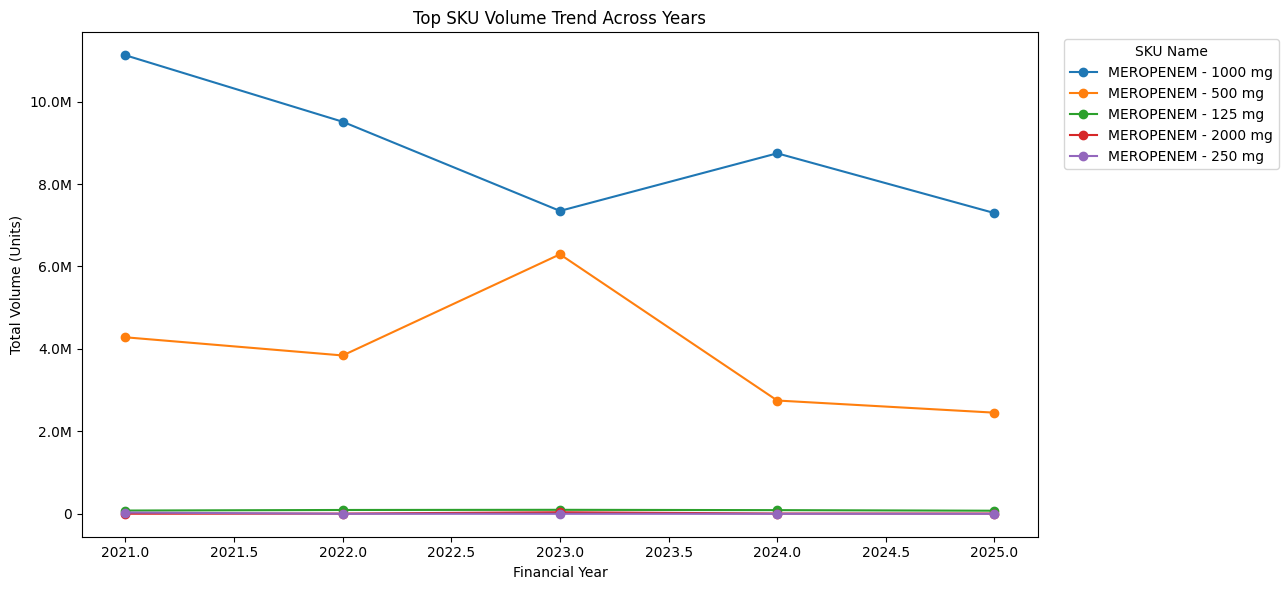

Fastest-growing SKUs from FY2024 to FY2025 (%):
SKU Name
MEROPENEM - 2000 mg    -0.40
MEROPENEM - 500 mg    -10.72
MEROPENEM - 125 mg    -15.97
MEROPENEM - 1000 mg   -16.58
dtype: float64
Biggest declining SKUs (%):
SKU Name
MEROPENEM - 1000 mg   -16.58
MEROPENEM - 125 mg    -15.97
MEROPENEM - 500 mg    -10.72
MEROPENEM - 2000 mg    -0.40
dtype: float64


In [201]:
# SKU trend comparison by year.
sku_year_volume = compare_df.groupby(['SKU Name', 'Financial Year'])['Total Qty'].sum().unstack(fill_value=0)

if latest_year_cmp in sku_year_volume.columns:
    top_skus_latest = sku_year_volume[latest_year_cmp].sort_values(ascending=False).head(12).index
else:
    top_skus_latest = sku_year_volume.sum(axis=1).sort_values(ascending=False).head(12).index

sku_trend_top = sku_year_volume.loc[top_skus_latest].T
print(f'Top SKU trend table (based on FY{latest_year_cmp}):')
print(sku_trend_top)

ax = sku_trend_top.plot(marker='o', figsize=(13, 6))
ax.set_title('Top SKU Volume Trend Across Years')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Total Volume (Units)')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
ax.legend(title='SKU Name', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

if previous_year_cmp in sku_year_volume.columns and latest_year_cmp in sku_year_volume.columns:
    sku_growth_pct = ((sku_year_volume[latest_year_cmp] - sku_year_volume[previous_year_cmp]) /
                      sku_year_volume[previous_year_cmp].replace(0, np.nan)) * 100
    sku_growth_pct = sku_growth_pct.replace([np.inf, -np.inf], np.nan).dropna()

    print(f'Fastest-growing SKUs from FY{previous_year_cmp} to FY{latest_year_cmp} (%):')
    print(sku_growth_pct.sort_values(ascending=False).head(10).round(2))
    print('Biggest declining SKUs (%):')
    print(sku_growth_pct.sort_values().head(10).round(2))


### 40) Quarter Pattern for Top SKUs in Latest Year
Shows whether top SKUs are steady all year or concentrated in certain quarters.


Quarter pattern for top 5 SKUs in FY2025:
SKU Name  MEROPENEM - 1000 mg  MEROPENEM - 125 mg  MEROPENEM - 2000 mg  \
Quarter                                                                  
1                     1081891               20700                 1620   
2                     3401815               25272                  998   
3                     2812081               28728                 3826   
4                           0                   0                    0   

SKU Name  MEROPENEM - 500 mg  
Quarter                       
1                     593276  
2                     929850  
3                     930452  
4                          0  


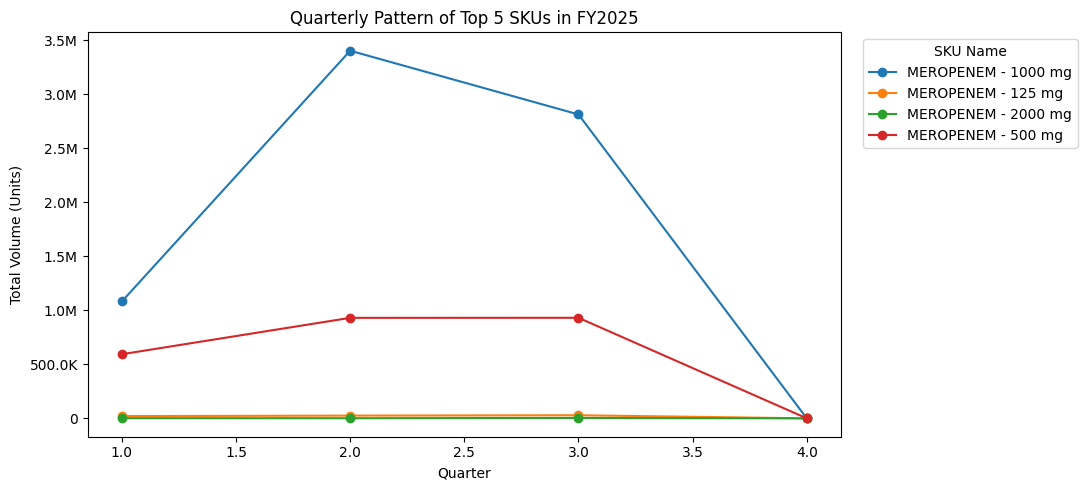

In [202]:
# Quarter-level profile for top 5 latest-year SKUs.
if latest_year_cmp in sku_year_volume.columns:
    top_5_skus = sku_year_volume[latest_year_cmp].sort_values(ascending=False).head(5).index
else:
    top_5_skus = sku_year_volume.sum(axis=1).sort_values(ascending=False).head(5).index

sku_quarter_profile = latest_year_data[latest_year_data['SKU Name'].isin(top_5_skus)]     .groupby(['Quarter', 'SKU Name'])['Total Qty'].sum().unstack(fill_value=0)
sku_quarter_profile = sku_quarter_profile.reindex(index=[1, 2, 3, 4], fill_value=0)

print(f'Quarter pattern for top 5 SKUs in FY{latest_year_cmp}:')
print(sku_quarter_profile)

ax = sku_quarter_profile.plot(marker='o', figsize=(11, 5))
ax.set_title(f'Quarterly Pattern of Top 5 SKUs in FY{latest_year_cmp}')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Volume (Units)')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_number))
ax.legend(title='SKU Name', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
